Recherche des images...
Nombre total d'images trouvées initialement: 15000
Exemple de chemin d'image: .\leftImg8bit\test\berlin\berlin_000000_000019_leftImg8bit.png
Nombre total d'images valides: 15000
Nombre total de masks trouvés: 15000
Nombre d'images d'entraînement: 8925
Nombre d'images de validation: 1500
Nombre d'images de test: 4575
Analyse de 50 masques...
Traitement: 10/50 masques
Traitement: 20/50 masques
Traitement: 30/50 masques
Traitement: 40/50 masques
Traitement: 50/50 masques

=== Répartition des classes dans les masques ===
 ID   |    Pixels    | Pourcentage  | Mapping actuel
--------------------------------------------------
  0   |     1125     |     0.00    % |      0      
  1   |   4076700    |     3.89    % |      0      
  3   |   1581700    |     1.51    % |      0      
  4   |   1316058    |     1.26    % |      0      
  5   |    144442    |     0.14    % |      0      
  6   |    642129    |     0.61    % |      0      
  7   |   38692097   |    36.90    % 

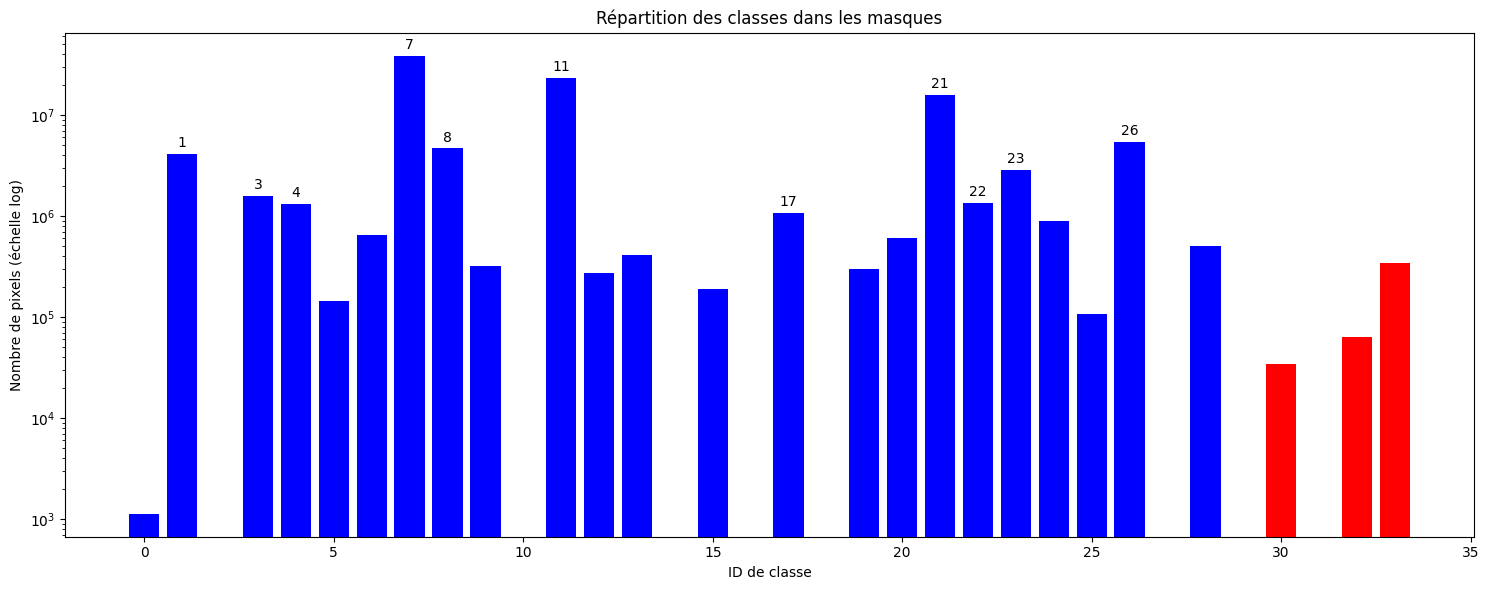


=== Suggestion pour le CLASS_MAPPING ===
CLASS_MAPPING = {
    0: 0,  # 0.00%
    1: 0,  # 3.89%
    3: 0,  # 1.51%
    4: 0,  # 1.26%
    5: 0,  # 0.14%
    6: 0,  # 0.61%
    7: 1,  # 36.90%
    8: 2,  # 4.45%
    9: 0,  # 0.30%
    11: 3,  # 22.04%
    12: 0,  # 0.26%
    13: 0,  # 0.39%
    15: 0,  # 0.18%
    17: 0,  # 1.02%
    19: 0,  # 0.29%
    20: 0,  # 0.58%
    21: 4,  # 15.15%
    22: 0,  # 1.27%
    23: 0,  # 2.72%
    24: 5,  # 0.85%
    25: 0,  # 0.10%
    26: 6,  # 5.20%
    28: 7,  # 0.48%
    # 30: 0,  # 0.03% - Classe rare
    # 32: 0,  # 0.06% - Classe rare
    # 33: 0,  # 0.33% - Classe rare
}
Analyse de 20 masques...
Traitement: 10/20 masques
Traitement: 20/20 masques

=== Répartition des classes dans les masques ===
 ID   |    Pixels    | Pourcentage  | Mapping actuel
--------------------------------------------------
  1   |   2421920    |     5.77    % |      0      
  2   |   1481960    |     3.53    % |      0      
  3   |    632680    |     1.51    % |   

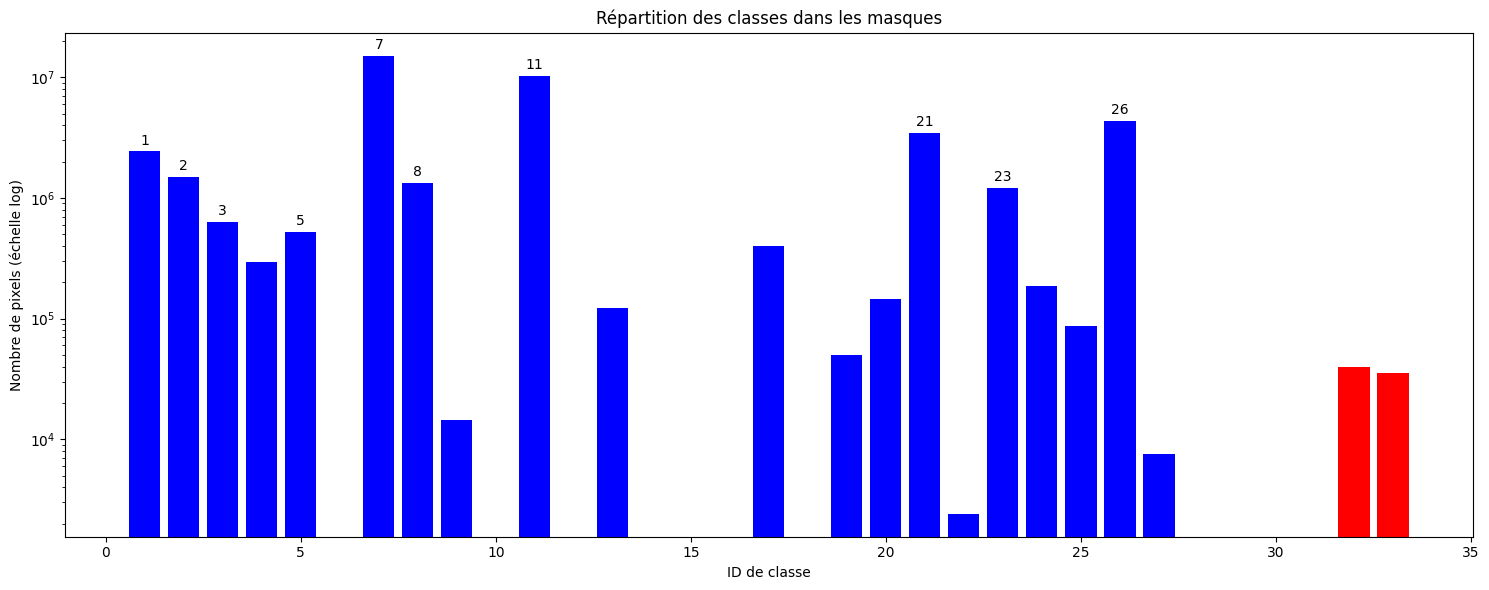


=== Suggestion pour le CLASS_MAPPING ===
CLASS_MAPPING = {
    1: 0,  # 5.77%
    2: 0,  # 3.53%
    3: 0,  # 1.51%
    4: 0,  # 0.71%
    5: 0,  # 1.25%
    7: 1,  # 35.89%
    8: 2,  # 3.18%
    9: 0,  # 0.03%
    11: 3,  # 24.20%
    13: 0,  # 0.29%
    17: 0,  # 0.95%
    19: 0,  # 0.12%
    20: 0,  # 0.34%
    21: 4,  # 8.18%
    22: 0,  # 0.01%
    23: 0,  # 2.89%
    24: 5,  # 0.44%
    25: 0,  # 0.21%
    26: 6,  # 10.28%
    27: 0,  # 0.02%
    # 32: 0,  # 0.09% - Classe rare
    # 33: 0,  # 0.09% - Classe rare
}
Analyse de 10 masques...
Traitement: 10/10 masques

=== Répartition des classes dans les masques ===
 ID   |    Pixels    | Pourcentage  | Mapping actuel
--------------------------------------------------
  0   |   19839840   |    94.60    % |      0      
  1   |    815340    |     3.89    % |      0      
  3   |    316340    |     1.51    % |      0      


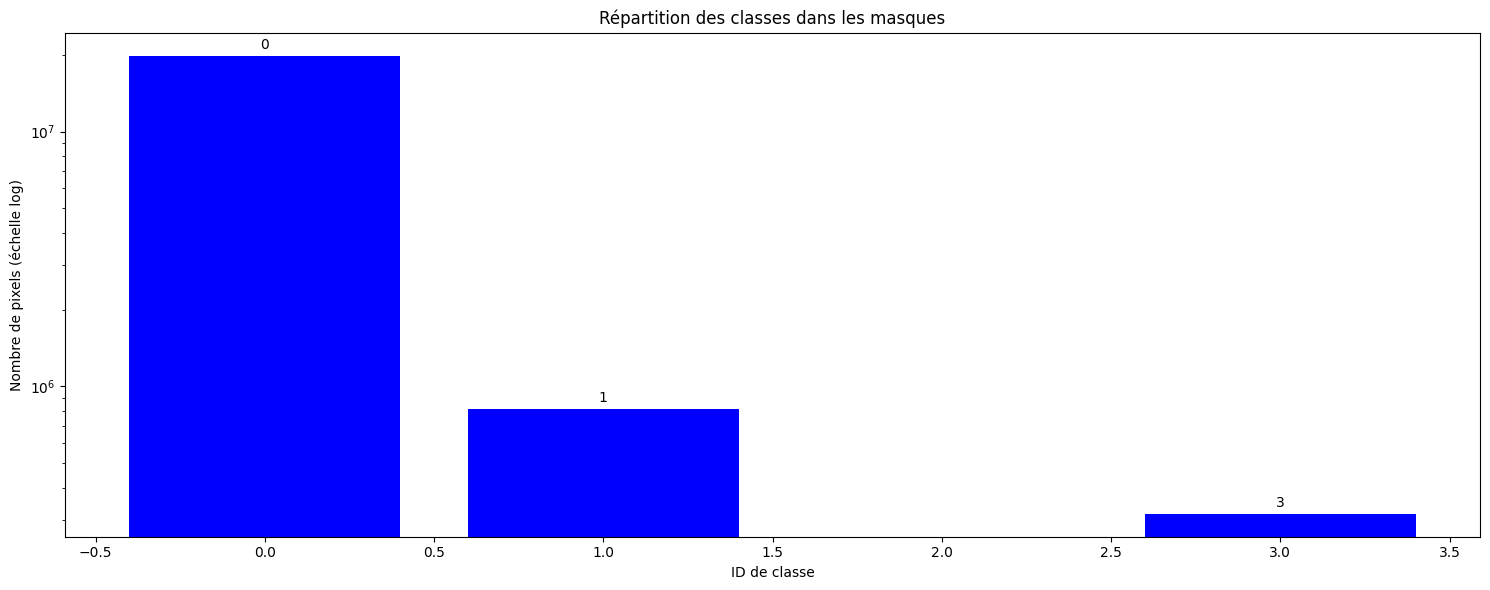


=== Suggestion pour le CLASS_MAPPING ===
CLASS_MAPPING = {
    0: 0,  # 94.60%
    1: 0,  # 3.89%
    3: 0,  # 1.51%
}


In [40]:
def analyze_mask_classes(mask_paths, num_samples=None, show_histogram=True):
    """
    Analyse la répartition des classes dans les masques.
    
    Args:
        mask_paths: Liste des chemins vers les masques
        num_samples: Nombre de masques à analyser (None pour tous)
        show_histogram: Afficher un histogramme des classes
    """
    # Limiter le nombre d'échantillons si spécifié
    if num_samples is not None:
        mask_paths = mask_paths[:num_samples]
    
    # Dictionnaire pour compter la fréquence de chaque classe
    class_counts = {}
    total_pixels = 0
    
    print(f"Analyse de {len(mask_paths)} masques...")
    
    for i, mask_path in enumerate(mask_paths):
        # Charger le masque
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            print(f"⚠️ Impossible de charger le masque {mask_path}")
            continue
        
        # Compter les valeurs uniques dans ce masque
        unique_vals, counts = np.unique(mask, return_counts=True)
        total_pixels += mask.size
        
        # Mettre à jour le compteur global
        for val, count in zip(unique_vals, counts):
            if val in class_counts:
                class_counts[val] += count
            else:
                class_counts[val] = count
        
        # Afficher la progression
        if (i+1) % 10 == 0:
            print(f"Traitement: {i+1}/{len(mask_paths)} masques")
    
    # Trier les classes par ID
    sorted_classes = sorted(class_counts.items())
    
    # Calculer les pourcentages
    percentages = {cls: (count / total_pixels) * 100 for cls, count in class_counts.items()}
    
    # Afficher les résultats
    print("\n=== Répartition des classes dans les masques ===")
    print(f"{'ID':^5} | {'Pixels':^12} | {'Pourcentage':^12} | {'Mapping actuel':^12}")
    print("-" * 50)
    
    # Pour vérifier quelles classes sont mappées actuellement
    current_mapping = {}
    for k in CLASS_MAPPING:
        current_mapping[k] = CLASS_MAPPING[k]
    
    for cls, count in sorted_classes:
        pct = percentages[cls]
        mapping = current_mapping.get(cls, "Non mappé")
        print(f"{cls:^5} | {count:^12} | {pct:^12.2f}% | {mapping:^12}")
    
    # Afficher un histogramme
    if show_histogram and len(sorted_classes) > 0:
        plt.figure(figsize=(15, 6))
        
        # Données pour le graphique
        class_ids = [cls for cls, _ in sorted_classes]
        counts = [count for _, count in sorted_classes]
        
        # Ajouter des couleurs différentes pour les classes mappées vs non mappées
        colors = ['blue' if cls in CLASS_MAPPING else 'red' for cls in class_ids]
        
        # Créer le graphique en barres
        plt.bar(class_ids, counts, color=colors)
        plt.yscale('log')  # Échelle logarithmique pour mieux voir les classes rares
        plt.xlabel('ID de classe')
        plt.ylabel('Nombre de pixels (échelle log)')
        plt.title('Répartition des classes dans les masques')
        
        # Ajouter des annotations pour les classes les plus fréquentes
        for i, (cls, count) in enumerate(sorted_classes):
            if percentages[cls] > 1.0:  # Annoter seulement les classes > 1%
                plt.annotate(f"{cls}", (cls, count), 
                             textcoords="offset points", 
                             xytext=(0,5), 
                             ha='center')
        
        plt.tight_layout()
        plt.show()
    
    # Suggestion pour le mapping
    print("\n=== Suggestion pour le CLASS_MAPPING ===")
    print("CLASS_MAPPING = {")
    
    # Classes existantes dans le mapping actuel
    for cls, count in sorted_classes:
        if cls in CLASS_MAPPING:
            print(f"    {cls}: {CLASS_MAPPING[cls]},  # {percentages[cls]:.2f}%")
        else:
            # Suggérer un mapping pour les classes non mappées
            if percentages[cls] > 0.5:  # Seuil arbitraire, à ajuster
                print(f"    {cls}: 0,  # {percentages[cls]:.2f}% - Non mappé, à considérer")
            else:
                print(f"    # {cls}: 0,  # {percentages[cls]:.2f}% - Classe rare")
    
    print("}")

# 1. Charger d'abord les données
train_img_paths, train_mask_paths, val_img_paths, val_mask_paths, test_img_paths, test_mask_paths = load_data()

# 2. Puis analyser les masques selon vos besoins
# Pour les masques d'entraînement:
analyze_mask_classes(train_mask_paths, num_samples=50)

# Pour les masques de validation:
analyze_mask_classes(val_mask_paths, num_samples=20)

# Pour les masques de test:
analyze_mask_classes(test_mask_paths, num_samples=10)


Analyse des masques d'entraînement (8925 masques)...


100%|██████████| 8925/8925 [05:23<00:00, 27.56it/s]



Analyse des masques de validation (1500 masques)...


100%|██████████| 1500/1500 [00:55<00:00, 27.24it/s]



Analyse des masques de test (4575 masques)...


100%|██████████| 4575/4575 [02:30<00:00, 30.46it/s]



=== RÉPARTITION DES CLASSES DANS L'ENSEMBLE DU JEU DE DONNÉES ===
 ID   |         Nom          |  Train %   |   Val %    |   Test %   |  Mapping  
----------------------------------------------------------------------
  0   |      unlabeled       |    0.01    |    0.04    |   92.90    |     0     
  1   |     ego vehicle      |    4.58    |    4.90    |    4.48    |     0     
  2   | rectification border |    1.30    |    1.89    |    1.11    |     0     
  3   |      out of roi      |    1.51    |    1.51    |    1.51    |     0     
  4   |        static        |    1.34    |    1.49    |    0.00    |     0     
  5   |       dynamic        |    0.29    |    0.42    |    0.00    |     0     
  6   |        ground        |    1.21    |    1.78    |    0.00    |     0     
  7   |         road         |   32.64    |   32.93    |    0.00    |     1     
  8   |       sidewalk       |    5.39    |    4.73    |    0.00    |     2     
  9   |       parking        |    0.63    |    0.40 

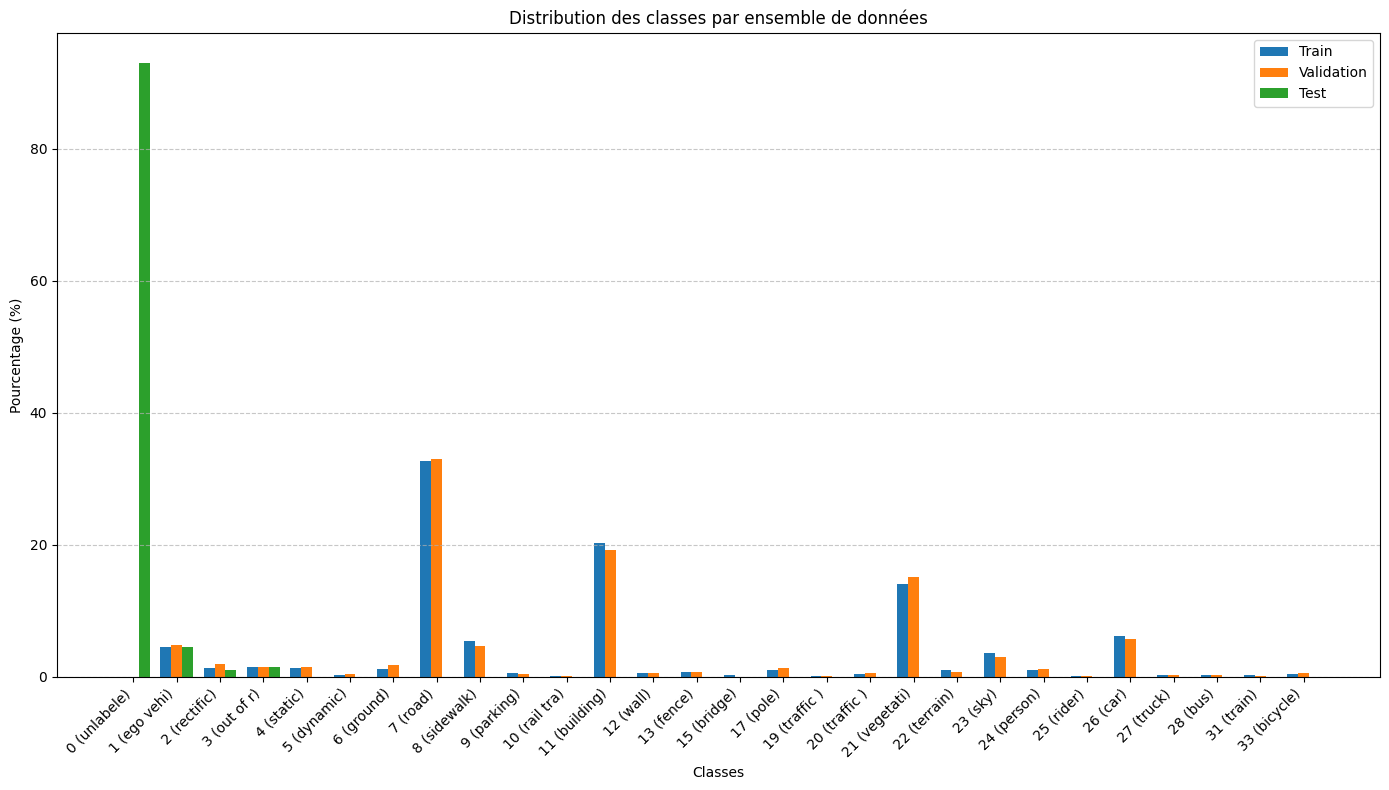


=== PROPOSITION DE MAPPING AMÉLIORÉ ===
Basé sur la distribution des classes dans tout le jeu de données:
CLASS_MAPPING = {
    # Classes de fond (background)
    2: 0,  # rectification border - 1.38%
    3: 0,  # out of roi - 1.51%
    4: 0,  # static - 1.10%
    5: 0,  # dynamic - 0.26%
    6: 0,  # ground - 1.08%
    9: 0,  # parking - 0.45%
    10: 0,  # rail track - 0.12%
    12: 0,  # wall - 0.48%
    13: 0,  # fence - 0.61%
    14: 0,  # guard rail - 0.01%
    15: 0,  # bridge - 0.18%
    16: 0,  # tunnel - 0.03%
    17: 0,  # pole - 0.91%
    18: 0,  # polegroup - 0.01%
    19: 0,  # traffic light - 0.14%
    20: 0,  # traffic sign - 0.41%
    22: 0,  # terrain - 0.76%
    24: 0,  # person - 0.87%
    25: 0,  # rider - 0.11%
    27: 0,  # truck - 0.19%
    28: 0,  # bus - 0.19%
    29: 0,  # caravan - 0.02%
    30: 0,  # trailer - 0.02%
    31: 0,  # train - 0.14%
    32: 0,  # motorcycle - 0.07%
    33: 0,  # bicycle - 0.34%

    # Classes principales
    7: 0,  # road - 26.1

In [41]:
def analyze_full_dataset_classes(train_mask_paths, val_mask_paths, test_mask_paths, sample_ratio=1.0):
    """
    Analyse complète de la répartition des classes dans tout le jeu de données,
    avec comparaison entre train/val/test.
    
    Args:
        train_mask_paths: Liste des chemins vers les masques d'entraînement
        val_mask_paths: Liste des chemins vers les masques de validation
        test_mask_paths: Liste des chemins vers les masques de test
        sample_ratio: Proportion des données à analyser (1.0 = 100%)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import cv2
    import random
    from tqdm import tqdm
    
    # Dictionnaire des noms de classes Cityscapes
    CITYSCAPES_CLASSES = {
        0: "unlabeled",
        1: "ego vehicle",
        2: "rectification border",
        3: "out of roi",
        4: "static",
        5: "dynamic",
        6: "ground",
        7: "road",
        8: "sidewalk",
        9: "parking",
        10: "rail track",
        11: "building",
        12: "wall",
        13: "fence",
        14: "guard rail",
        15: "bridge",
        16: "tunnel",
        17: "pole",
        18: "polegroup",
        19: "traffic light",
        20: "traffic sign",
        21: "vegetation",
        22: "terrain",
        23: "sky",
        24: "person",
        25: "rider",
        26: "car",
        27: "truck",
        28: "bus",
        29: "caravan",
        30: "trailer",
        31: "train",
        32: "motorcycle",
        33: "bicycle",
        -1: "license plate"
    }
    
    # Échantillonnage aléatoire si demandé
    if sample_ratio < 1.0:
        random.seed(42)  # Pour reproduire les résultats
        train_mask_paths = random.sample(train_mask_paths, int(len(train_mask_paths) * sample_ratio))
        val_mask_paths = random.sample(val_mask_paths, int(len(val_mask_paths) * sample_ratio))
        test_mask_paths = random.sample(test_mask_paths, int(len(test_mask_paths) * sample_ratio))
    
    # Dictionnaires pour compter les classes par division
    train_counts = {}
    val_counts = {}
    test_counts = {}
    
    # Pixels totaux par division
    train_total_pixels = 0
    val_total_pixels = 0
    test_total_pixels = 0
    
    # Analyse des masques d'entraînement
    print(f"\nAnalyse des masques d'entraînement ({len(train_mask_paths)} masques)...")
    for mask_path in tqdm(train_mask_paths):
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            continue
            
        train_total_pixels += mask.size
        unique_vals, counts = np.unique(mask, return_counts=True)
        
        for val, count in zip(unique_vals, counts):
            if val in train_counts:
                train_counts[val] += count
            else:
                train_counts[val] = count
    
    # Analyse des masques de validation
    print(f"\nAnalyse des masques de validation ({len(val_mask_paths)} masques)...")
    for mask_path in tqdm(val_mask_paths):
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            continue
            
        val_total_pixels += mask.size
        unique_vals, counts = np.unique(mask, return_counts=True)
        
        for val, count in zip(unique_vals, counts):
            if val in val_counts:
                val_counts[val] += count
            else:
                val_counts[val] = count
    
    # Analyse des masques de test
    print(f"\nAnalyse des masques de test ({len(test_mask_paths)} masques)...")
    for mask_path in tqdm(test_mask_paths):
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            continue
            
        test_total_pixels += mask.size
        unique_vals, counts = np.unique(mask, return_counts=True)
        
        for val, count in zip(unique_vals, counts):
            if val in test_counts:
                test_counts[val] += count
            else:
                test_counts[val] = count
    
    # Tous les IDs de classe uniques trouvés dans tout le jeu de données
    all_classes = sorted(set().union(train_counts.keys(), val_counts.keys(), test_counts.keys()))
    
    # Calculer les pourcentages
    train_percentages = {cls: (train_counts.get(cls, 0) / train_total_pixels) * 100 for cls in all_classes}
    val_percentages = {cls: (val_counts.get(cls, 0) / val_total_pixels) * 100 for cls in all_classes}
    test_percentages = {cls: (test_counts.get(cls, 0) / test_total_pixels) * 100 for cls in all_classes}
    
    # Déterminer le mapping actuel (pour référence)
    current_mapping = {}
    for k in CLASS_MAPPING:
        current_mapping[k] = CLASS_MAPPING[k]
    
    # Afficher les résultats
    print("\n=== RÉPARTITION DES CLASSES DANS L'ENSEMBLE DU JEU DE DONNÉES ===")
    print(f"{'ID':^5} | {'Nom':^20} | {'Train %':^10} | {'Val %':^10} | {'Test %':^10} | {'Mapping':^10}")
    print("-" * 70)
    
    # Pour stocker les données pour les graphiques
    plot_classes = []
    plot_train = []
    plot_val = []
    plot_test = []
    
    for cls in all_classes:
        class_name = CITYSCAPES_CLASSES.get(cls, "Unknown")
        train_pct = train_percentages.get(cls, 0)
        val_pct = val_percentages.get(cls, 0)
        test_pct = test_percentages.get(cls, 0)
        mapping = current_mapping.get(cls, "Non mappé")
        
        # Ne montrer que les classes avec une présence significative
        if train_pct > 0.1 or val_pct > 0.1 or test_pct > 0.1:
            print(f"{cls:^5} | {class_name[:20]:^20} | {train_pct:^10.2f} | {val_pct:^10.2f} | {test_pct:^10.2f} | {mapping:^10}")
            
            # Stocker pour le graphique
            plot_classes.append(f"{cls} ({class_name[:8]})")
            plot_train.append(train_pct)
            plot_val.append(val_pct)
            plot_test.append(test_pct)
    
    # Visualisation des différences entre train/val/test
    plt.figure(figsize=(14, 8))
    x = np.arange(len(plot_classes))
    width = 0.25
    
    plt.bar(x - width, plot_train, width, label='Train')
    plt.bar(x, plot_val, width, label='Validation')
    plt.bar(x + width, plot_test, width, label='Test')
    
    plt.xlabel('Classes')
    plt.ylabel('Pourcentage (%)')
    plt.title('Distribution des classes par ensemble de données')
    plt.xticks(x, plot_classes, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    # Proposition de mapping amélioré
    print("\n=== PROPOSITION DE MAPPING AMÉLIORÉ ===")
    print("Basé sur la distribution des classes dans tout le jeu de données:")
    
    # Obtenir les IDs des classes les plus fréquentes
    all_percentages = {}
    for cls in all_classes:
        # Moyenne pondérée des pourcentages (train compte plus)
        all_percentages[cls] = (train_percentages.get(cls, 0) * 0.6 + 
                              val_percentages.get(cls, 0) * 0.2 + 
                              test_percentages.get(cls, 0) * 0.2)
    
    # Top classes par fréquence
    top_classes = sorted(all_percentages.items(), key=lambda x: x[1], reverse=True)
    
    # Suggérer un mapping optimisé
    print("CLASS_MAPPING = {")
    
    # Classes de fond
    print("    # Classes de fond (background)")
    for cls, pct in all_percentages.items():
        if cls not in [c[0] for c in top_classes[:8]] and cls in CITYSCAPES_CLASSES:
            class_name = CITYSCAPES_CLASSES.get(cls, "Unknown")
            print(f"    {cls}: 0,  # {class_name} - {pct:.2f}%")
    
    print("\n    # Classes principales")
    # Conserver les classes principales (top 7 après le background)
    for i, (cls, pct) in enumerate(top_classes[:8]):
        if i == 0:
            target = 0  # La classe la plus fréquente devient le fond
        else:
            target = i  # Les 7 suivantes sont mappées de 1 à 7
        class_name = CITYSCAPES_CLASSES.get(cls, "Unknown")
        print(f"    {cls}: {target},  # {class_name} - {pct:.2f}%")
    
    print("}")

# Exemple d'utilisation
analyze_full_dataset_classes(train_mask_paths, val_mask_paths, test_mask_paths)

# Pour une analyse sur un échantillon (plus rapide mais moins précis)
# analyze_full_dataset_classes(train_mask_paths, val_mask_paths, test_mask_paths, sample_ratio=0.2)

Restructuration du jeu de données

In [42]:
def restructure_dataset(img_paths, mask_paths, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Restructure le jeu de données en nouveaux ensembles train/val/test équilibrés
    
    Args:
        img_paths: Liste de tous les chemins d'images
        mask_paths: Liste de tous les chemins de masques
        train_ratio, val_ratio, test_ratio: Ratios pour chaque ensemble
        seed: Graine pour la reproductibilité
    """
    import numpy as np
    from sklearn.model_selection import train_test_split
    
    assert len(img_paths) == len(mask_paths), "Le nombre d'images et de masques doit être identique"
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-5, "Les ratios doivent sommer à 1"
    
    # Regrouper les anciens ensembles (en ignorant probablement le test qui semble défectueux)
    all_img_paths = []
    all_mask_paths = []
    
    for img_path, mask_path in zip(img_paths, mask_paths):
        # Vérifier que le masque contient des annotations utiles
        # (optionnel - si vous voulez filtrer les masques majoritairement unlabeled)
        mask = cv2.imread(mask_path, 0)
        if mask is not None:
            # Compter combien de pixels ne sont pas de classe 0
            non_zero_ratio = np.sum(mask > 0) / mask.size
            if non_zero_ratio > 0.05:  # Au moins 5% d'annotations utiles
                all_img_paths.append(img_path)
                all_mask_paths.append(mask_path)
    
    print(f"Total d'images valides: {len(all_img_paths)}")
    
    # Premier split: train vs reste
    train_img_paths, temp_img_paths, train_mask_paths, temp_mask_paths = train_test_split(
        all_img_paths, all_mask_paths, train_size=train_ratio, random_state=seed
    )
    
    # Second split: val vs test
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
    val_img_paths, test_img_paths, val_mask_paths, test_mask_paths = train_test_split(
        temp_img_paths, temp_mask_paths, train_size=val_ratio_adjusted, random_state=seed
    )
    
    print(f"Nouvel ensemble d'entraînement: {len(train_img_paths)} images")
    print(f"Nouvel ensemble de validation: {len(val_img_paths)} images")
    print(f"Nouvel ensemble de test: {len(test_img_paths)} images")
    
    return (train_img_paths, train_mask_paths, 
            val_img_paths, val_mask_paths, 
            test_img_paths, test_mask_paths)

Recherche des images...
Nombre total d'images trouvées initialement: 15000
Exemple de chemin d'image: .\leftImg8bit\test\berlin\berlin_000000_000019_leftImg8bit.png
Nombre total d'images valides: 15000
Nombre total de masks trouvés: 15000
Nombre d'images d'entraînement: 8925
Nombre d'images de validation: 1500
Nombre d'images de test: 4575
Total d'images valides: 10425
Nouvel ensemble d'entraînement: 7297 images
Nouvel ensemble de validation: 1564 images
Nouvel ensemble de test: 1564 images

Analyse des masques d'entraînement (1459 masques)...


100%|██████████| 1459/1459 [00:46<00:00, 31.07it/s]



Analyse des masques de validation (312 masques)...


100%|██████████| 312/312 [00:10<00:00, 31.05it/s]



Analyse des masques de test (312 masques)...


100%|██████████| 312/312 [00:10<00:00, 30.72it/s]



=== RÉPARTITION DES CLASSES DANS L'ENSEMBLE DU JEU DE DONNÉES ===
 ID   |         Nom          |  Train %   |   Val %    |   Test %   |  Mapping  
----------------------------------------------------------------------
  1   |     ego vehicle      |    4.62    |    4.65    |    4.61    |     0     
  2   | rectification border |    1.37    |    1.43    |    1.35    |     0     
  3   |      out of roi      |    1.51    |    1.51    |    1.51    |     0     
  4   |        static        |    1.37    |    1.38    |    1.38    |     0     
  5   |       dynamic        |    0.32    |    0.27    |    0.28    |     0     
  6   |        ground        |    1.13    |    0.68    |    1.27    |     0     
  7   |         road         |   32.94    |   32.80    |   32.95    |     1     
  8   |       sidewalk       |    5.35    |    5.72    |    5.23    |     2     
  9   |       parking        |    0.56    |    0.62    |    0.53    |     0     
 10   |      rail track      |    0.15    |    0.19 

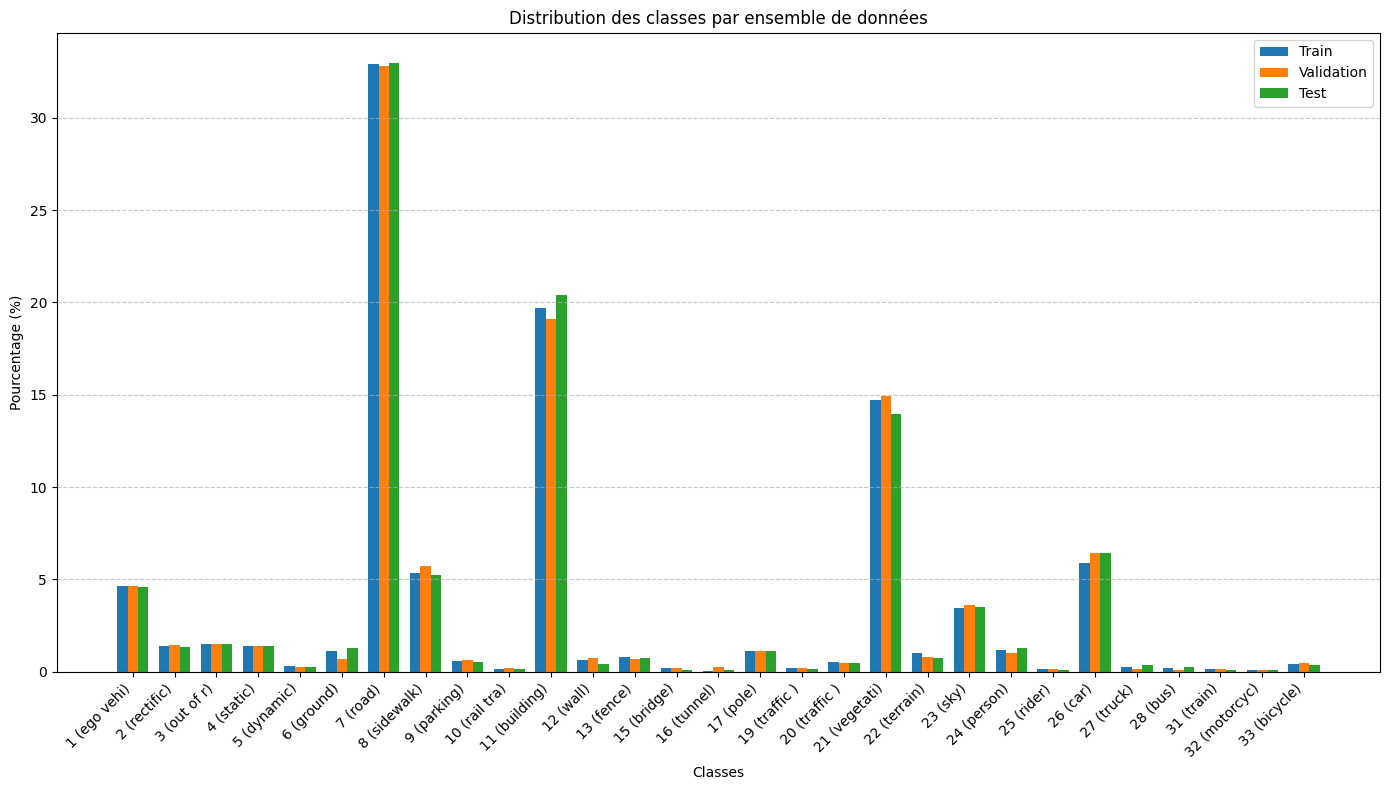


=== PROPOSITION DE MAPPING AMÉLIORÉ ===
Basé sur la distribution des classes dans tout le jeu de données:
CLASS_MAPPING = {
    # Classes de fond (background)
    0: 0,  # unlabeled - 0.02%
    2: 0,  # rectification border - 1.38%
    4: 0,  # static - 1.37%
    5: 0,  # dynamic - 0.30%
    6: 0,  # ground - 1.06%
    9: 0,  # parking - 0.57%
    10: 0,  # rail track - 0.15%
    12: 0,  # wall - 0.60%
    13: 0,  # fence - 0.74%
    14: 0,  # guard rail - 0.01%
    15: 0,  # bridge - 0.18%
    16: 0,  # tunnel - 0.09%
    17: 0,  # pole - 1.13%
    18: 0,  # polegroup - 0.01%
    19: 0,  # traffic light - 0.18%
    20: 0,  # traffic sign - 0.50%
    22: 0,  # terrain - 0.92%
    24: 0,  # person - 1.15%
    25: 0,  # rider - 0.12%
    27: 0,  # truck - 0.24%
    28: 0,  # bus - 0.18%
    29: 0,  # caravan - 0.04%
    30: 0,  # trailer - 0.03%
    31: 0,  # train - 0.15%
    32: 0,  # motorcycle - 0.09%
    33: 0,  # bicycle - 0.41%

    # Classes principales
    7: 0,  # road - 32.91

In [43]:
# Chargement des données originales
train_img_paths_orig, train_mask_paths_orig, val_img_paths_orig, val_mask_paths_orig, test_img_paths_orig, test_mask_paths_orig = load_data()

# Combiner tous les chemins (ou seulement train+val si le test est inutilisable)
all_img_paths = train_img_paths_orig + val_img_paths_orig
all_mask_paths = train_mask_paths_orig + val_mask_paths_orig

# Restructurer le jeu de données
train_img_paths, train_mask_paths, val_img_paths, val_mask_paths, test_img_paths, test_mask_paths = restructure_dataset(
    all_img_paths, all_mask_paths
)

# Vérifier la nouvelle distribution
analyze_full_dataset_classes(train_mask_paths, val_mask_paths, test_mask_paths, sample_ratio=0.2)

In [3]:
def save_dataset_paths(train_img, train_mask, val_img, val_mask, test_img, test_mask, filename="dataset_paths.npz"):
    """Sauvegarde les chemins des fichiers du dataset restructuré."""
    np.savez(
        filename, 
        train_img=train_img, train_mask=train_mask,
        val_img=val_img, val_mask=val_mask,
        test_img=test_img, test_mask=test_mask
    )
    print(f"Chemins du dataset sauvegardés dans {filename}")

def load_dataset_paths(filename="dataset_paths.npz"):
    """Charge les chemins des fichiers du dataset restructuré."""
    if os.path.exists(filename):
        data = np.load(filename, allow_pickle=True)
        return (
            data['train_img'].tolist(), data['train_mask'].tolist(),
            data['val_img'].tolist(), data['val_mask'].tolist(),
            data['test_img'].tolist(), data['test_mask'].tolist()
        )
    return None

Configuration initiale et import des bibliothèques

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import VGG16
from sklearn.model_selection import train_test_split
import albumentations as A
from tensorflow.keras import backend as K
import random
import time

# Activer la mémoire GPU limitée si nécessaire
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Configuration des paramètres généraux
IMG_HEIGHT = 128
IMG_WIDTH = 256
NUM_CLASSES = 8  # 8 classes spécifiées
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Chemin vers les dossiers de données
DATA_DIR = "."  # Ajustez selon votre structure
IMG_DIR = os.path.join(DATA_DIR, "leftImg8bit")
MASK_DIR = os.path.join(DATA_DIR, "gtFine")

# Définition des classes à considérer mises à jour basée sur la nouvelle distribution
CLASS_MAPPING = {
    # Classes de fond
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 9: 0, 10: 0,
    12: 0, 13: 0, 15: 0, 16: 0, 19: 0, 20: 0, 22: 0,
    25: 0, 27: 0, 32: 0,
    
    # Classes principales (par ordre d'importance/fréquence)
    7: 1,   # Road (~33%)
    11: 2,  # Building (~20%)
    21: 3,  # Vegetation (~15%)
    26: 4,  # Car (~6%)
    8: 5,   # Sidewalk (~5%)
    23: 6,  # Sky (~3.5%) - Nouvelle classe importante
    24: 7,  # Person (~1.2%) - Plus important sémantiquement que Bus
    
    # Classes à considérer pour un mapping futur si vous augmentez NUM_CLASSES
    28: 0,  # Bus (~0.2%) - Remap à background ou groupe avec Car
    31: 0,  # Train (~0.1%)
    33: 0,  # Bicycle (~0.4%)
    17: 0   # Pole (~1.1%)
}

#Mapper les ID originaux aux nouvelles classes (0-7)
def map_masks(mask):
    out_mask = np.zeros(mask.shape, dtype=np.uint8)
    
    # Mapper les classes connues sans afficher de statistiques de débogage à chaque fois
    for k in CLASS_MAPPING:
        out_mask[mask == k] = CLASS_MAPPING[k]
    
    return out_mask

# Ajoutez cette ligne après les déclarations DATA_DIR, IMG_DIR et MASK_DIR
RESTRUCTURED_DATA_PATH = os.environ.get("RESTRUCTURED_DATA_PATH", "dataset_paths.npz")

c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Générateur de données

In [7]:
class DataGenerator(Sequence):
    def __init__(self, img_paths, mask_paths, batch_size, img_size, augmentation=None, shuffle=True, training=True):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.img_size = img_size
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.training = training
        self.on_epoch_end()
        
    def __len__(self):
        return len(self.img_paths) // self.batch_size
    
    def on_epoch_end(self):
        self.indexes = np.arange(len(self.img_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def __getitem__(self, index):
        # Générer les indices du batch
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        
        # Initialiser les arrays de batch
        batch_imgs = np.empty((self.batch_size, self.img_size[0], self.img_size[1], 3), dtype=np.float32)
        batch_masks = np.empty((self.batch_size, self.img_size[0], self.img_size[1], NUM_CLASSES), dtype=np.float32)
        
        # Générer le batch
        for i, idx in enumerate(indexes):
            img_path = self.img_paths[idx]
            mask_path = self.mask_paths[idx]
            
            # Charger l'image et le mask
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, 0)  # Charger en niveaux de gris
            
            # Redimensionner
            img = cv2.resize(img, (self.img_size[1], self.img_size[0]))
            mask = cv2.resize(mask, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_NEAREST)
            
            # Appliquer la transformation de classe
            mask = map_masks(mask)
            
            # Appliquer l'augmentation si définie
            if self.augmentation:
                augmented = self.augmentation(image=img, mask=mask)
                img = augmented['image']
                mask = augmented['mask']
            
            # Normaliser l'image
            img = img / 255.0
            
            # Convertir le masque en one-hot encoding - CORRECTION ICI
            # Utiliser la forme actuelle du masque au lieu de self.img_size
            mask_onehot = np.zeros((mask.shape[0], mask.shape[1], NUM_CLASSES))
            for cls in range(NUM_CLASSES):
                mask_onehot[:, :, cls] = (mask == cls).astype(np.float32)
            
            # Redimensionner le mask_onehot si nécessaire pour correspondre à batch_masks
            if mask_onehot.shape[:2] != (self.img_size[0], self.img_size[1]):
                # Créer un nouveau tableau avec la forme attendue
                resized_mask = np.zeros((self.img_size[0], self.img_size[1], NUM_CLASSES))
                # Utiliser le redimensionnement pour chaque canal
                for c in range(NUM_CLASSES):
                    resized_mask[:, :, c] = cv2.resize(mask_onehot[:, :, c], 
                                                    (self.img_size[1], self.img_size[0]),
                                                    interpolation=cv2.INTER_NEAREST)
                mask_onehot = resized_mask
            
            # Ajouter au batch
            batch_imgs[i] = img if img.shape[:2] == (self.img_size[0], self.img_size[1]) else \
                        cv2.resize(img, (self.img_size[1], self.img_size[0]))
            batch_masks[i] = mask_onehot
            
        return batch_imgs, batch_masks

Fonctions de loss et métriques

In [8]:
# Définir les métriques et fonctions de perte
def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1.0):
    intersection = K.sum(K.abs(y_true * y_pred), axis=-1)
    union = K.sum(y_true, axis=-1) + K.sum(y_pred, axis=-1) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

# Combiner avec cross-entropy pour total_loss
def total_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)

# Métrique personnalisée pour IoU moyen sur toutes les classes
@tf.function
def mean_iou(y_true, y_pred):
    # Récupérer les formes actuelles
    true_shape = tf.shape(y_true)
    pred_shape = tf.shape(y_pred)
    
    # Créer la condition pour les dimensions différentes
    shape_condition = tf.logical_or(
        tf.not_equal(true_shape[1], pred_shape[1]),
        tf.not_equal(true_shape[2], pred_shape[2])
    )
    
    # Fonction pour redimensionner y_pred si nécessaire
    def resize_branch():
        y_pred_argmax = tf.argmax(y_pred, axis=-1)
        y_pred_float = tf.cast(y_pred_argmax, tf.float32)
        y_pred_resized = tf.image.resize(
            tf.expand_dims(y_pred_float, axis=-1),
            [true_shape[1], true_shape[2]]
        )
        return tf.squeeze(y_pred_resized, axis=-1)
    
    # Fonction si pas besoin de redimensionner
    def no_resize_branch():
        y_pred_argmax = tf.argmax(y_pred, axis=-1)
        return tf.cast(y_pred_argmax, tf.float32)
    
    # Appliquer la condition
    y_pred_processed = tf.cond(shape_condition, resize_branch, no_resize_branch)
    
    # Obtenir les classes pour y_true
    y_true_argmax = tf.argmax(y_true, axis=-1)
    y_true_float = tf.cast(y_true_argmax, tf.float32)
    
    # Calculer l'IoU pour chaque classe
    scores = []
    for cls in range(1, NUM_CLASSES):  # Ignorer la classe background (0)
        true_class = tf.cast(tf.equal(y_true_float, cls), tf.float32)
        pred_class = tf.cast(tf.equal(y_pred_processed, cls), tf.float32)
        
        intersection = tf.reduce_sum(true_class * pred_class)
        union = tf.reduce_sum(true_class) + tf.reduce_sum(pred_class) - intersection
        
        iou = (intersection + tf.keras.backend.epsilon()) / (union + tf.keras.backend.epsilon())
        scores.append(iou)
    
    return tf.reduce_mean(tf.stack(scores)) if scores else tf.constant(0.0)

Définition des architectures de modèles

In [9]:
# 1. U-Net Mini Lightweight
def unet_mini_lightweight(input_shape):
    inputs = keras.Input(shape=input_shape)
    
    # Encoder
    c1 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    c2 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    c3 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    
    # Bridge
    c4 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    c4 = layers.BatchNormalization()(c4)
    
    # Decoder
    u5 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u5)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    c5 = layers.BatchNormalization()(c5)
    
    u6 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = layers.BatchNormalization()(c6)
    c6 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    c6 = layers.BatchNormalization()(c6)
    
    u7 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = layers.BatchNormalization()(c7)
    c7 = layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    c7 = layers.BatchNormalization()(c7)
    
    outputs = layers.Conv2D(NUM_CLASSES, (1, 1), activation='softmax')(c7)
    
    model = keras.Model(inputs=[inputs], outputs=[outputs])
    
    return model

# 2. U-Net standard
def unet_standard(input_shape):
    inputs = keras.Input(shape=input_shape)
    
    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = layers.Dropout(0.1)(c1)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    c2 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = layers.Dropout(0.1)(c2)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    c3 = layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = layers.Dropout(0.2)(c3)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    
    c4 = layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = layers.Dropout(0.2)(c4)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = layers.MaxPooling2D(pool_size=(2, 2))(c4)
    
    # Bridge
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = layers.Dropout(0.3)(c5)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = layers.Dropout(0.2)(c6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    
    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = layers.Dropout(0.2)(c7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    
    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = layers.Dropout(0.1)(c8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    
    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1], axis=3)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = layers.Dropout(0.1)(c9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    
    outputs = layers.Conv2D(NUM_CLASSES, (1, 1), activation='softmax')(c9)
    
    model = keras.Model(inputs=[inputs], outputs=[outputs])
    
    return model

# 3. VGG16 pour la segmentation
def vgg16_segmentation(input_shape):
    # Chargement du modèle VGG16 pré-entraîné sans les couches fully connected
    vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Geler les couches du VGG16 (optionnel)
    for layer in vgg16.layers:
        layer.trainable = False
    
    # Extraire les features aux différents niveaux pour les skip connections
    s1 = vgg16.get_layer('block1_conv2').output  # 64 filters
    s2 = vgg16.get_layer('block2_conv2').output  # 128 filters
    s3 = vgg16.get_layer('block3_conv3').output  # 256 filters
    s4 = vgg16.get_layer('block4_conv3').output  # 512 filters
    
    # Dernière couche de l'encodeur
    s5 = vgg16.get_layer('block5_conv3').output  # 512 filters
    
    # Décodeur
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(s5)
    u6 = layers.concatenate([u6, s4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = layers.Dropout(0.2)(c6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
    
    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, s3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = layers.Dropout(0.2)(c7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
    
    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, s2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = layers.Dropout(0.1)(c8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
    
    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, s1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = layers.Dropout(0.1)(c9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
    
    # Upsampling final pour revenir à la taille d'origine
    u10 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c9)
    c10 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u10)
    c10 = layers.Dropout(0.1)(c10)
    c10 = layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c10)
    
    # Ajout d'une couche de redimensionnement explicite pour garantir les bonnes dimensions
    # Cette couche assurera que la sortie est de la même taille que l'entrée
    pre_output = layers.Conv2D(NUM_CLASSES, (1, 1))(c10)
    
    # Redimensionner explicitement à la taille d'entrée
    resized = layers.Lambda(lambda x: tf.image.resize(x, input_shape[:2]))(pre_output)
    
    # Appliquer softmax après redimensionnement
    outputs = layers.Activation('softmax')(resized)
    
    model = keras.Model(inputs=vgg16.input, outputs=outputs)
    
    return model

Configuration de la data augmentation

In [10]:
# Configuration de la data augmentation
def get_training_augmentation():
    train_transform = [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.RandomRotate90(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.OneOf(
            [
                A.GaussNoise(p=1),
                A.GaussianBlur(p=1),
                A.MotionBlur(p=1),
            ],
            p=0.2,
        ),
        A.OneOf(
            [
                A.CLAHE(clip_limit=2, p=1),
                A.RandomGamma(p=1),
                A.HueSaturationValue(p=1),
            ],
            p=0.2,
        ),
    ]
    return A.Compose(train_transform)

def get_validation_augmentation():
    # No augmentation for validation
    return None

# Configuration du preprocessing
def get_preprocessing():
    # Si nécessaire, ajoutez ici des opérations de prétraitement spécifiques
    return None

Chargement des données et préparation

In [11]:
def load_data():
    # Trouver toutes les images
    print("Recherche des images...")
    all_img_paths = sorted(glob(os.path.join(IMG_DIR, "**", "**", "*_leftImg8bit.png"), recursive=True))
    print(f"Nombre total d'images trouvées initialement: {len(all_img_paths)}")
    
    # Construire les chemins vers les masks correspondants
    all_mask_paths = []
    valid_img_paths = []
    
    # Imprimer quelques exemples de chemins pour déboguer
    if all_img_paths:
        print(f"Exemple de chemin d'image: {all_img_paths[0]}")
    
    for img_path in all_img_paths:
        # Extraction des éléments du chemin
        img_parts = img_path.split(os.sep)
        
        # Récupérer les informations de structure
        # Le format est: leftImg8bit/[split]/[city]/xxx_leftImg8bit.png
        if len(img_parts) >= 4:
            split = img_parts[-3]  # train, val ou test
            city = img_parts[-2]   # berlin, bielefeld, etc.
            filename = os.path.basename(img_path).replace("_leftImg8bit.png", "")
            
            # Construction du chemin vers le mask correspondant
            mask_path = os.path.join(MASK_DIR, split, city, f"{filename}_gtFine_labelIds.png")
            
            # Vérification si le mask existe
            if os.path.exists(mask_path):
                valid_img_paths.append(img_path)
                all_mask_paths.append(mask_path)
            else:
                print(f"Mask non trouvé pour {img_path}")
                print(f"Chemin de mask recherché: {mask_path}")
        else:
            print(f"Structure de chemin incorrecte pour {img_path}")
    
    print(f"Nombre total d'images valides: {len(valid_img_paths)}")
    print(f"Nombre total de masks trouvés: {len(all_mask_paths)}")
    
    # Vérifier si des données ont été trouvées
    if len(valid_img_paths) == 0:
        raise ValueError("Aucune paire d'image/masque valide n'a été trouvée. Vérifiez les chemins des dossiers.")
    
    # Diviser les données en ensembles d'entraînement, de validation et de test
    train_img_paths = [p for p in valid_img_paths if os.sep + "train" + os.sep in p.replace("\\", os.sep)]
    val_img_paths = [p for p in valid_img_paths if os.sep + "val" + os.sep in p.replace("\\", os.sep)]
    test_img_paths = [p for p in valid_img_paths if os.sep + "test" + os.sep in p.replace("\\", os.sep)]
    
    train_mask_paths = [p for p in all_mask_paths if os.sep + "train" + os.sep in p.replace("\\", os.sep)]
    val_mask_paths = [p for p in all_mask_paths if os.sep + "val" + os.sep in p.replace("\\", os.sep)]
    test_mask_paths = [p for p in all_mask_paths if os.sep + "test" + os.sep in p.replace("\\", os.sep)]
    
    print(f"Nombre d'images d'entraînement: {len(train_img_paths)}")
    print(f"Nombre d'images de validation: {len(val_img_paths)}")
    print(f"Nombre d'images de test: {len(test_img_paths)}")
    
    
    return (train_img_paths, train_mask_paths, 
            val_img_paths, val_mask_paths, 
            test_img_paths, test_mask_paths)

# Afficher quelques exemples d'images et de masks
def visualize_samples(img_paths, mask_paths, num_samples=3):
    for i in range(min(num_samples, len(img_paths))):
        img = cv2.imread(img_paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_paths[i], 0)
        
        # Redimensionner
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
        
        # Mapper les classes
        mask = map_masks(mask)
        
        # Afficher
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(img)
        axes[0].set_title('Image')
        axes[0].axis('off')
        
        # Créer une version colorée du masque
        colored_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
        colors = [
            [0, 0, 0],        # Background
            [128, 64, 128],   # Road
            [244, 35, 232],   # Building
            [70, 70, 70],     # Vegetation
            [107, 142, 35],   # Car
            [153, 153, 153],  # Sidewalk
            [0, 191, 255],    # Sky
            [220, 20, 60]     # Person
        ]
        
        for cls, color in enumerate(colors):
            colored_mask[mask == cls] = color
            
        axes[1].imshow(colored_mask)
        axes[1].set_title('Mask')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

In [12]:
def verify_masks(mask_paths, num_samples=3):
    """Vérifie que les masques sont chargés correctement et montre leurs valeurs."""
    for i in range(min(num_samples, len(mask_paths))):
        # Charger le masque
        mask = cv2.imread(mask_paths[i], 0)
        if mask is None:
            print(f"Impossible de charger le masque {mask_paths[i]}")
            continue
            
        # Afficher les statistiques
        print(f"\nMasque {i+1}: {mask_paths[i]}")
        print(f"Dimensions: {mask.shape}")
        print(f"Valeurs min/max: {mask.min()}/{mask.max()}")
        print(f"Valeurs uniques: {np.unique(mask)}")
        
        # Afficher le masque
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(mask, cmap='gray')
        plt.title('Masque original')
        plt.colorbar()
        
        # Mapper et afficher
        mapped_mask = map_masks(mask)
        plt.subplot(1, 2, 2)
        plt.imshow(mapped_mask, cmap='viridis')
        plt.title('Masque mappé')
        plt.colorbar()
        
        plt.tight_layout()
        plt.show()


Entraînement et évaluation des modèles

In [13]:
def train_model(model, model_name, train_gen, val_gen, loss_func, epochs=50):
    # Callbacks
    model_checkpoint = ModelCheckpoint(
        f"{model_name}_best.h5", 
        monitor='val_mean_iou', 
        mode='max', 
        save_best_only=True, 
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_mean_iou', 
        mode='max', 
        patience=10, 
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_mean_iou', 
        mode='max', 
        factor=0.5, 
        patience=5, 
        min_lr=1e-6, 
        verbose=1
    )
    
    # Compiler le modèle
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss=loss_func,
        metrics=[dice_coef, mean_iou, 'accuracy']
    )
    
    # Entraînement
    start_time = time.time()
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=[model_checkpoint, early_stopping, reduce_lr]
    )
    end_time = time.time()
    training_time = end_time - start_time
    
    print(f"Temps d'entraînement pour {model_name}: {training_time:.2f} secondes")
    
    # Charger les poids du meilleur modèle
    model.load_weights(f"{model_name}_best.h5")
    
    return model, history

def evaluate_model(model, test_gen, model_name):
    print(f"\nÉvaluation du modèle {model_name} sur l'ensemble de test:")
    test_scores = model.evaluate(test_gen, verbose=1)
    print(f"Loss: {test_scores[0]:.4f}")
    print(f"Dice Coefficient: {test_scores[1]:.4f}")
    print(f"IoU: {test_scores[2]:.4f}")
    print(f"Accuracy: {test_scores[3]:.4f}")
    return test_scores

def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))
    
    # Tracer l'évolution de la loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train loss')
    plt.plot(history.history['val_loss'], label='Validation loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Tracer l'évolution de l'IoU
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_iou'], label='Train IoU')
    plt.plot(history.history['val_mean_iou'], label='Validation IoU')
    plt.title(f'{model_name} - IoU')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, test_img_paths, test_mask_paths, num_samples=3):
    # Afficher les prédictions sur quelques exemples
    for i in range(min(num_samples, len(test_img_paths))):
        img_path = test_img_paths[i]
        mask_path = test_mask_paths[i]
        
        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Impossible de charger l'image {img_path}")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, 0)  # Charger en niveaux de gris
        
        if mask is None:
            print(f"⚠️ Impossible de charger le masque {mask_path}")
            continue
            
        # Debug - Afficher les valeurs uniques dans le masque original
        unique_vals = np.unique(mask)
        print(f"Valeurs uniques dans le masque original: {unique_vals}")
        
        # Redimensionner
        img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        mask_resized = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
        
        # Mapper les classes
        mask_mapped = map_masks(mask_resized)
        
        # Debug - Afficher les valeurs uniques après mapping
        unique_mapped = np.unique(mask_mapped)
        print(f"Valeurs uniques après mapping: {unique_mapped}")
        
        # Prédiction
        img_normalized = img_resized / 255.0
        pred = model.predict(np.expand_dims(img_normalized, axis=0))[0]
        pred_mask = np.argmax(pred, axis=-1)
        
        # Debug - Afficher les valeurs uniques dans la prédiction
        unique_pred = np.unique(pred_mask)
        print(f"Valeurs uniques dans la prédiction: {unique_pred}")
        
        # Créer des versions colorées des masques
        colors = [
            [0, 0, 0],        # Background
            [128, 64, 128],   # Road
            [244, 35, 232],   # Building
            [70, 70, 70],     # Vegetation
            [107, 142, 35],   # Car
            [153, 153, 153],  # Sidewalk
            [0, 191, 255],    # Sky
            [220, 20, 60]     # Person
        ]
        
        true_colored_mask = np.zeros((*mask_mapped.shape, 3), dtype=np.uint8)
        pred_colored_mask = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
        
        for cls, color in enumerate(colors):
            true_colored_mask[mask_mapped == cls] = color
            pred_colored_mask[pred_mask == cls] = color
        
        # Affichage
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(img_resized)
        axes[0].set_title('Image')
        axes[0].axis('off')
        
        axes[1].imshow(true_colored_mask)
        axes[1].set_title(f'Mask GT (classes: {unique_mapped})')
        axes[1].axis('off')
        
        axes[2].imshow(pred_colored_mask)
        axes[2].set_title(f'Prédiction (classes: {unique_pred})')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

Pipeline principale

Chargement des chemins du dataset restructuré...

Masque 1: .\gtFine\train\darmstadt\darmstadt_000083_000019_gtFine_labelIds.png
Dimensions: (1024, 2048)
Valeurs min/max: 0/33
Valeurs uniques: [ 0  1  3  4  5  6  7  8 11 12 13 17 20 21 22 23 24 25 26 27 33]


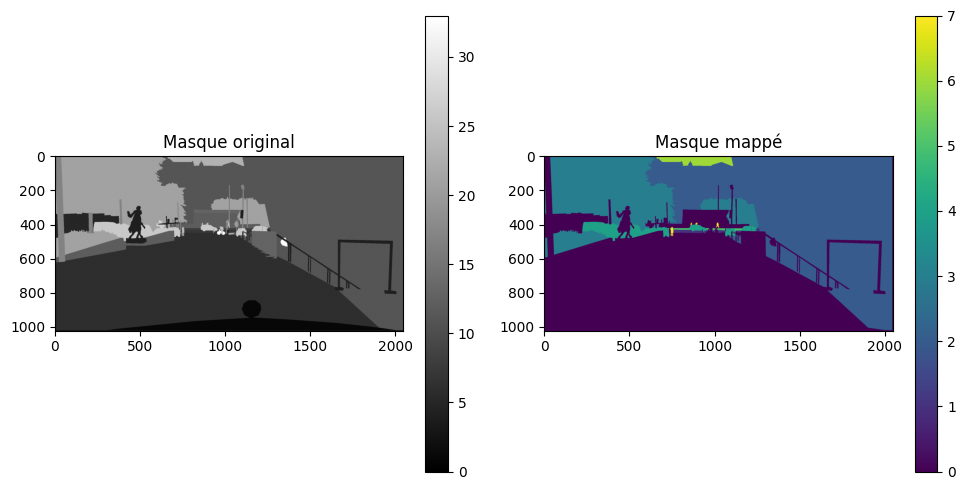


Masque 2: .\gtFine\train\monchengladbach\monchengladbach_000000_012672_gtFine_labelIds.png
Dimensions: (1024, 2048)
Valeurs min/max: 1/26
Valeurs uniques: [ 1  2  3  4  7  8  9 11 17 19 20 21 22 23 24 26]


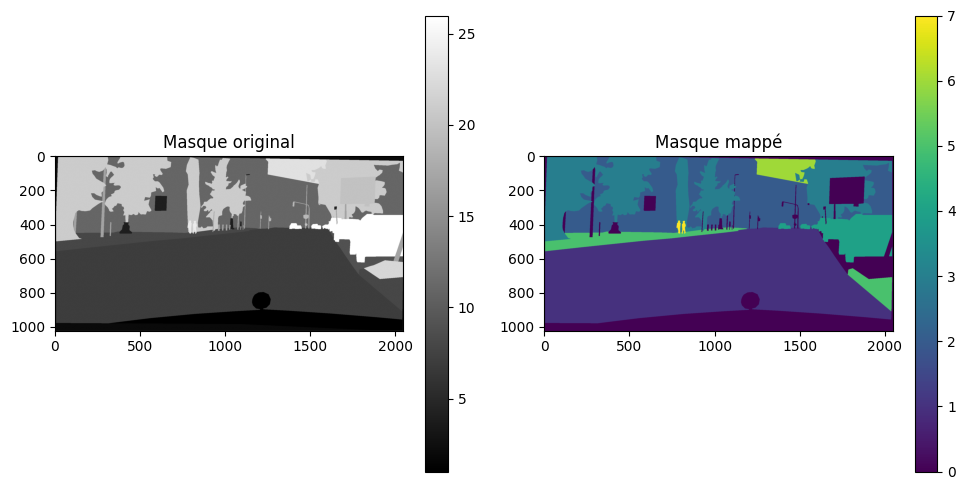

Visualisation de quelques exemples...


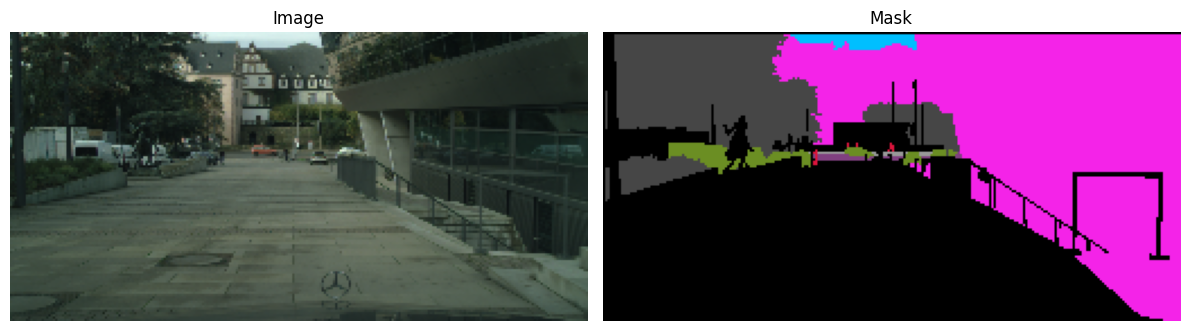

Configuration des générateurs de données...

Entraînement de U-Net Mini Lightweight sans data augmentation...
Epoch 1/5


c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1326']
Received: inputs=Tensor(shape=(None, 128, 256, 3))
  warnings.warn(msg)


912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.5145 - dice_coef: 0.4138 - loss: 0.5862 - mean_iou: 0.2534
Epoch 1: val_mean_iou improved from -inf to 0.41637, saving model to unet_mini_no_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 1014s 1s/step - accuracy: 0.5146 - dice_coef: 0.4140 - loss: 0.5860 - mean_iou: 0.2535 - val_accuracy: 0.7317 - val_dice_coef: 0.6979 - val_loss: 0.3021 - val_mean_iou: 0.4164 - learning_rate: 1.0000e-04
Epoch 2/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.7524 - dice_coef: 0.7215 - loss: 0.2785 - mean_iou: 0.4583
Epoch 2: val_mean_iou improved from 0.41637 to 0.49693, saving model to unet_mini_no_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 985s 1s/step - accuracy: 0.7524 - dice_coef: 0.7215 - loss: 0.2785 - mean_iou: 0.4583 - val_accuracy: 0.7765 - val_dice_coef: 0.7631 - val_loss: 0.2369 - val_mean_iou: 0.4969 - learning_rate: 1.0000e-04
Epoch 3/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.7816 - dice_coef: 0.7696 - loss: 0.2304 - mean_iou: 0.5057
Epoch 3: val_mean_iou improved from 0.49693 to 0.52163, saving model to unet_mini_no_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 981s 1s/step - accuracy: 0.7816 - dice_coef: 0.7696 - loss: 0.2304 - mean_iou: 0.5057 - val_accuracy: 0.7953 - val_dice_coef: 0.7885 - val_loss: 0.2115 - val_mean_iou: 0.5216 - learning_rate: 1.0000e-04
Epoch 4/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.7944 - dice_coef: 0.7880 - loss: 0.2120 - mean_iou: 0.5227
Epoch 4: val_mean_iou improved from 0.52163 to 0.53189, saving model to unet_mini_no_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 983s 1s/step - accuracy: 0.7944 - dice_coef: 0.7880 - loss: 0.2120 - mean_iou: 0.5227 - val_accuracy: 0.8035 - val_dice_coef: 0.7994 - val_loss: 0.2006 - val_mean_iou: 0.5319 - learning_rate: 1.0000e-04
Epoch 5/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.8022 - dice_coef: 0.7982 - loss: 0.2018 - mean_iou: 0.5318
Epoch 5: val_mean_iou improved from 0.53189 to 0.53489, saving model to unet_mini_no_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 986s 1s/step - accuracy: 0.8022 - dice_coef: 0.7982 - loss: 0.2018 - mean_iou: 0.5318 - val_accuracy: 0.8071 - val_dice_coef: 0.8044 - val_loss: 0.1956 - val_mean_iou: 0.5349 - learning_rate: 1.0000e-04
Temps d'entraînement pour unet_mini_no_aug: 4949.51 secondes

Évaluation du modèle U-Net Mini Lightweight (sans augmentation) sur l'ensemble de test:
195/195 ━━━━━━━━━━━━━━━━━━━━ 110s 562ms/step - accuracy: 0.8116 - dice_coef: 0.8089 - loss: 0.1911 - mean_iou: 0.5407
Loss: 0.1937
Dice Coefficient: 0.8063
IoU: 0.5381
Accuracy: 0.8090


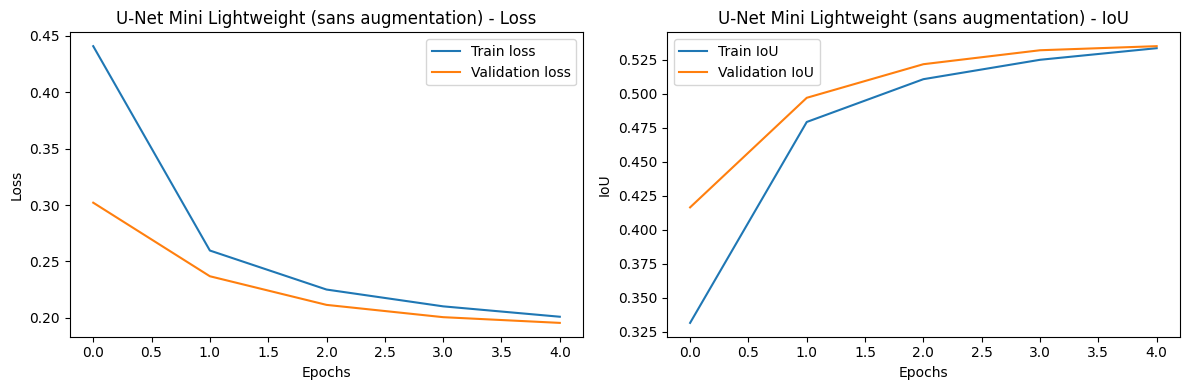

Valeurs uniques dans le masque original: [ 1  2  3  4  5  7  8  9 11 17 20 21 23 24 26]
Valeurs uniques après mapping: [0 1 2 3 4 5 6 7]


c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1326']
Received: inputs=Tensor(shape=(1, 128, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
Valeurs uniques dans la prédiction: [0 1 2 3 4 6]


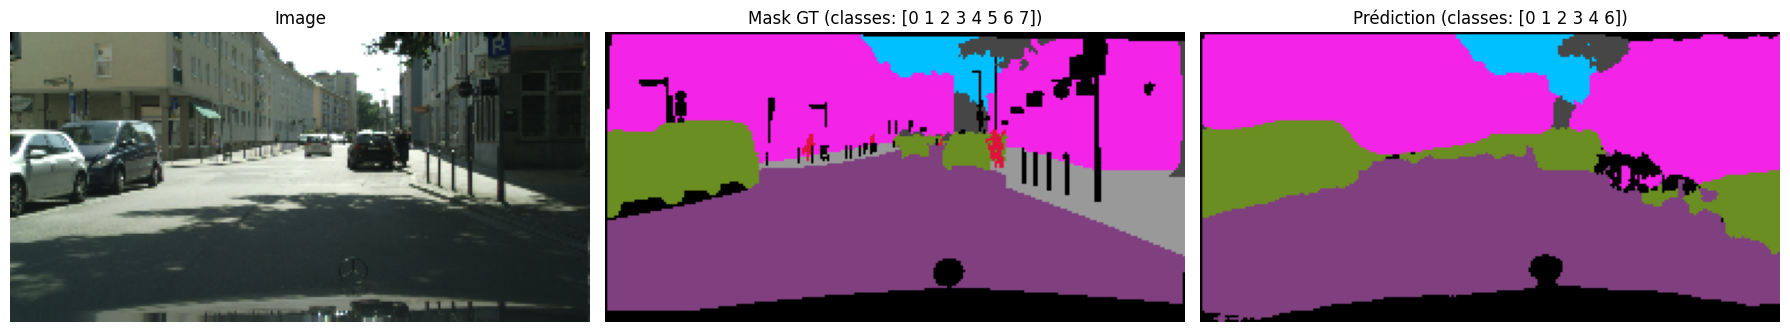


Entraînement de U-Net Mini Lightweight avec data augmentation...
Epoch 1/5


c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1365']
Received: inputs=Tensor(shape=(None, 128, 256, 3))
  warnings.warn(msg)


912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.4349 - dice_coef: 0.3736 - loss: 0.6264 - mean_iou: 0.1737
Epoch 1: val_mean_iou improved from -inf to 0.34807, saving model to unet_mini_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 1013s 1s/step - accuracy: 0.4350 - dice_coef: 0.3737 - loss: 0.6263 - mean_iou: 0.1738 - val_accuracy: 0.6722 - val_dice_coef: 0.6423 - val_loss: 0.3577 - val_mean_iou: 0.3481 - learning_rate: 1.0000e-04
Epoch 2/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 997ms/step - accuracy: 0.6603 - dice_coef: 0.6334 - loss: 0.3666 - mean_iou: 0.3291
Epoch 2: val_mean_iou improved from 0.34807 to 0.39460, saving model to unet_mini_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 1018s 1s/step - accuracy: 0.6603 - dice_coef: 0.6334 - loss: 0.3666 - mean_iou: 0.3291 - val_accuracy: 0.7202 - val_dice_coef: 0.7091 - val_loss: 0.2909 - val_mean_iou: 0.3946 - learning_rate: 1.0000e-04
Epoch 3/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.6860 - dice_coef: 0.6760 - loss: 0.3240 - mean_iou: 0.3552
Epoch 3: val_mean_iou improved from 0.39460 to 0.43188, saving model to unet_mini_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 1012s 1s/step - accuracy: 0.6860 - dice_coef: 0.6760 - loss: 0.3240 - mean_iou: 0.3553 - val_accuracy: 0.7349 - val_dice_coef: 0.7253 - val_loss: 0.2747 - val_mean_iou: 0.4319 - learning_rate: 1.0000e-04
Epoch 4/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - accuracy: 0.7125 - dice_coef: 0.7048 - loss: 0.2952 - mean_iou: 0.4126
Epoch 4: val_mean_iou improved from 0.43188 to 0.49470, saving model to unet_mini_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 1014s 1s/step - accuracy: 0.7125 - dice_coef: 0.7048 - loss: 0.2952 - mean_iou: 0.4126 - val_accuracy: 0.7702 - val_dice_coef: 0.7663 - val_loss: 0.2337 - val_mean_iou: 0.4947 - learning_rate: 1.0000e-04
Epoch 5/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7238 - dice_coef: 0.7200 - loss: 0.2800 - mean_iou: 0.4326
Epoch 5: val_mean_iou improved from 0.49470 to 0.50081, saving model to unet_mini_aug_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 1066s 1s/step - accuracy: 0.7238 - dice_coef: 0.7200 - loss: 0.2800 - mean_iou: 0.4326 - val_accuracy: 0.7747 - val_dice_coef: 0.7723 - val_loss: 0.2277 - val_mean_iou: 0.5008 - learning_rate: 1.0000e-04
Temps d'entraînement pour unet_mini_aug: 5124.40 secondes

Évaluation du modèle U-Net Mini Lightweight (avec augmentation) sur l'ensemble de test:
195/195 ━━━━━━━━━━━━━━━━━━━━ 116s 593ms/step - accuracy: 0.7798 - dice_coef: 0.7772 - loss: 0.2228 - mean_iou: 0.5063
Loss: 0.2249
Dice Coefficient: 0.7751
IoU: 0.5044
Accuracy: 0.7777


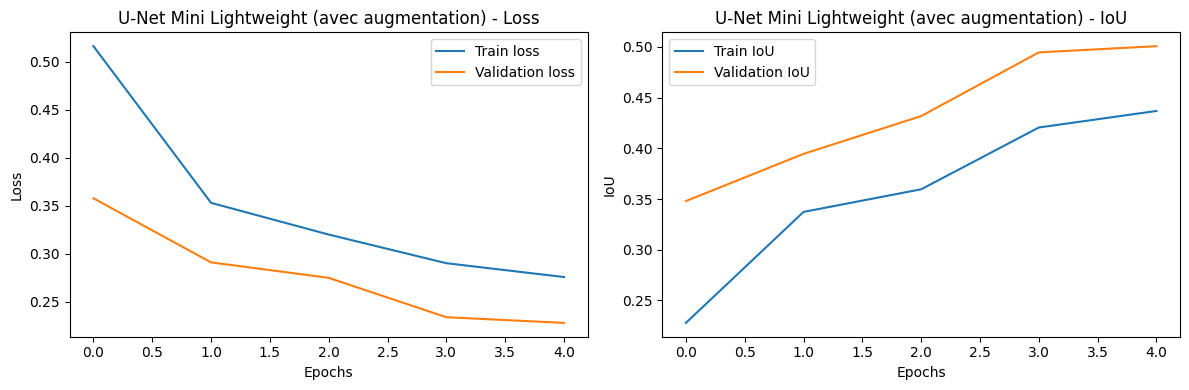

Valeurs uniques dans le masque original: [ 1  2  3  4  5  7  8  9 11 17 20 21 23 24 26]
Valeurs uniques après mapping: [0 1 2 3 4 5 6 7]


c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1365']
Received: inputs=Tensor(shape=(1, 128, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
Valeurs uniques dans la prédiction: [0 1 2 3 4 6]


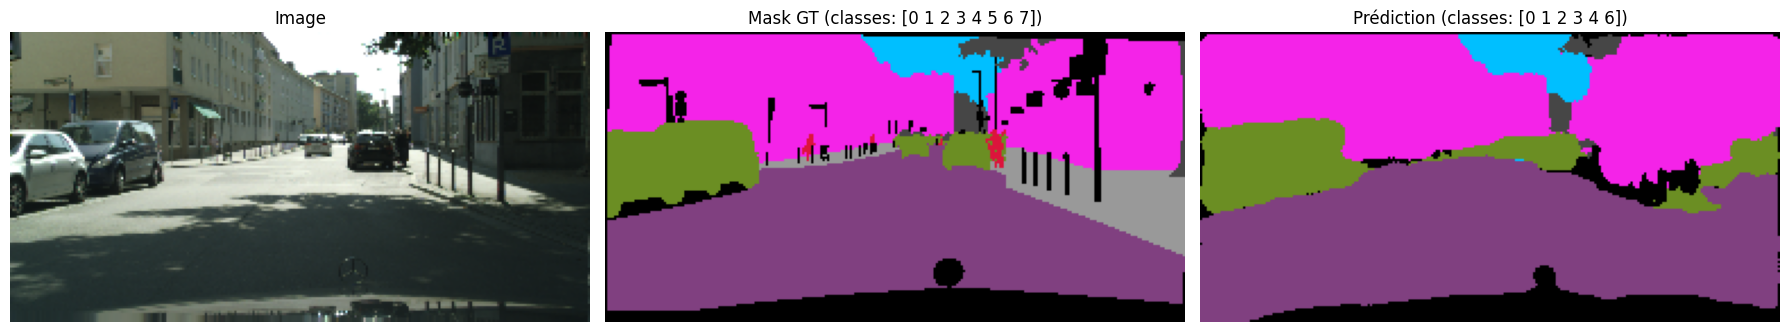


Entraînement de U-Net Mini Lightweight avec total_loss...
Epoch 1/5


c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1404']
Received: inputs=Tensor(shape=(None, 128, 256, 3))
  warnings.warn(msg)


912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4349 - dice_coef: 0.2985 - loss: 2.4069 - mean_iou: 0.1885
Epoch 1: val_mean_iou improved from -inf to 0.42756, saving model to unet_mini_total_loss_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 1208s 1s/step - accuracy: 0.4350 - dice_coef: 0.2986 - loss: 2.4064 - mean_iou: 0.1886 - val_accuracy: 0.7235 - val_dice_coef: 0.5893 - val_loss: 1.2875 - val_mean_iou: 0.4276 - learning_rate: 1.0000e-04
Epoch 2/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.6826 - dice_coef: 0.5559 - loss: 1.4379 - mean_iou: 0.3812
Epoch 2: val_mean_iou improved from 0.42756 to 0.48046, saving model to unet_mini_total_loss_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 979s 1s/step - accuracy: 0.6826 - dice_coef: 0.5559 - loss: 1.4378 - mean_iou: 0.3812 - val_accuracy: 0.7550 - val_dice_coef: 0.6568 - val_loss: 1.0825 - val_mean_iou: 0.4805 - learning_rate: 1.0000e-04
Epoch 3/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 951ms/step - accuracy: 0.7088 - dice_coef: 0.6122 - loss: 1.2648 - mean_iou: 0.4229
Epoch 3: val_mean_iou improved from 0.48046 to 0.52128, saving model to unet_mini_total_loss_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 976s 1s/step - accuracy: 0.7089 - dice_coef: 0.6122 - loss: 1.2647 - mean_iou: 0.4229 - val_accuracy: 0.7751 - val_dice_coef: 0.6931 - val_loss: 0.9719 - val_mean_iou: 0.5213 - learning_rate: 1.0000e-04
Epoch 4/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 956ms/step - accuracy: 0.7217 - dice_coef: 0.6361 - loss: 1.1880 - mean_iou: 0.4502
Epoch 4: val_mean_iou improved from 0.52128 to 0.54838, saving model to unet_mini_total_loss_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 982s 1s/step - accuracy: 0.7217 - dice_coef: 0.6361 - loss: 1.1879 - mean_iou: 0.4502 - val_accuracy: 0.7849 - val_dice_coef: 0.7105 - val_loss: 0.9247 - val_mean_iou: 0.5484 - learning_rate: 1.0000e-04
Epoch 5/5
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7338 - dice_coef: 0.6547 - loss: 1.1257 - mean_iou: 0.4718
Epoch 5: val_mean_iou improved from 0.54838 to 0.56107, saving model to unet_mini_total_loss_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 1066s 1s/step - accuracy: 0.7338 - dice_coef: 0.6547 - loss: 1.1256 - mean_iou: 0.4718 - val_accuracy: 0.7892 - val_dice_coef: 0.7187 - val_loss: 0.8887 - val_mean_iou: 0.5611 - learning_rate: 1.0000e-04
Temps d'entraînement pour unet_mini_total_loss: 5212.45 secondes

Évaluation du modèle U-Net Mini Lightweight (total_loss) sur l'ensemble de test:
195/195 ━━━━━━━━━━━━━━━━━━━━ 115s 588ms/step - accuracy: 0.7920 - dice_coef: 0.7204 - loss: 0.8769 - mean_iou: 0.5631
Loss: 0.8825
Dice Coefficient: 0.7190
IoU: 0.5618
Accuracy: 0.7907


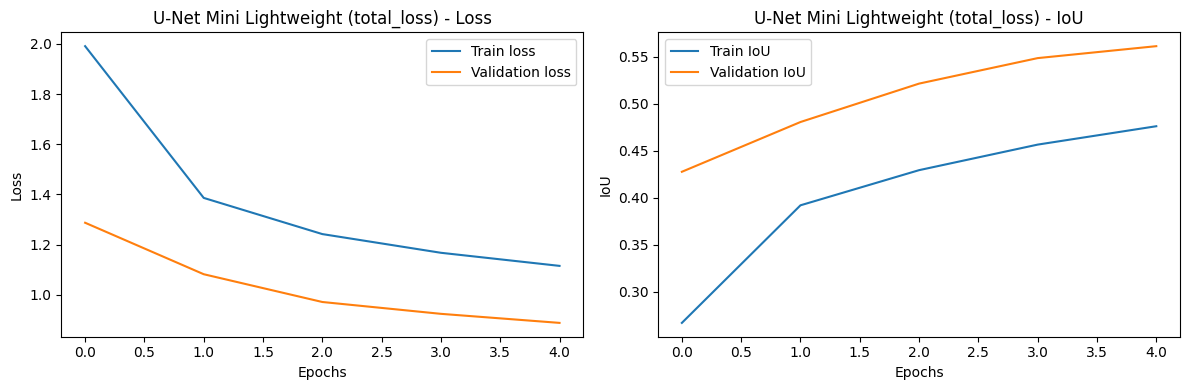


Entraînement de U-Net standard...
Epoch 1/15


c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1443']
Received: inputs=Tensor(shape=(None, 128, 256, 3))
  warnings.warn(msg)


912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3494 - dice_coef: 0.3468 - loss: 0.6532 - mean_iou: 0.0694
Epoch 1: val_mean_iou improved from -inf to 0.08099, saving model to unet_standard_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 8766s 10s/step - accuracy: 0.3494 - dice_coef: 0.3468 - loss: 0.6532 - mean_iou: 0.0694 - val_accuracy: 0.3760 - val_dice_coef: 0.3760 - val_loss: 0.6240 - val_mean_iou: 0.0810 - learning_rate: 1.0000e-04
Epoch 2/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.2476 - dice_coef: 0.2476 - loss: 0.7524 - mean_iou: 0.0215
Epoch 2: val_mean_iou did not improve from 0.08099
912/912 ━━━━━━━━━━━━━━━━━━━━ 8698s 10s/step - accuracy: 0.2476 - dice_coef: 0.2476 - loss: 0.7524 - mean_iou: 0.0214 - val_accuracy: 0.1691 - val_dice_coef: 0.1691 - val_loss: 0.8309 - val_mean_iou: 1.4126e-11 - learning_rate: 1.0000e-04
Epoch 3/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.1993 - dice_coef: 0.1993 - loss: 0.8007 - mean_iou: 1.8023e-08
Epoch 3: val_mean_iou did not improve from 0.08099
912/912 ━━━━━━━━━━━━━━━━━━━━ 8686s 10s/step - accuracy: 0.1993 - dice_coef: 0.1993 - loss: 0.8007 - mean_iou: 1.8021e-08 - val_accuracy: 0.1691 - val_dice_coef: 0.1691 - val_

In [ ]:
def main():
    # Vérifier si des chemins restructurés existent déjà
    paths = load_dataset_paths(RESTRUCTURED_DATA_PATH)
    
    # 1. chargement des données
    if paths is None:
        # Charger les données originales
        print("Chargement des données originales...")
        train_img_paths_orig, train_mask_paths_orig, val_img_paths_orig, val_mask_paths_orig, test_img_paths_orig, test_mask_paths_orig = load_data()
        
        # Combiner train+val pour restructurer (test est ignoré s'il était problématique)
        print("Restructuration du jeu de données...")
        all_img_paths = train_img_paths_orig + val_img_paths_orig
        all_mask_paths = train_mask_paths_orig + val_mask_paths_orig
        
        # Restructurer
        train_img_paths, train_mask_paths, val_img_paths, val_mask_paths, test_img_paths, test_mask_paths = restructure_dataset(
            all_img_paths, all_mask_paths
        )
        
        # Sauvegarder les chemins pour une utilisation future
        save_dataset_paths(train_img_paths, train_mask_paths, val_img_paths, val_mask_paths, test_img_paths, test_mask_paths, RESTRUCTURED_DATA_PATH)
    else:
        print("Chargement des chemins du dataset restructuré...")
        train_img_paths, train_mask_paths, val_img_paths, val_mask_paths, test_img_paths, test_mask_paths = paths 

    verify_masks(train_mask_paths, num_samples=2)  # Vérifier les masques d'entraînement
    
    # 2. Visualiser quelques exemples
    print("Visualisation de quelques exemples...")
    visualize_samples(train_img_paths, train_mask_paths, num_samples=1)  # Un seul exemple suffit
    
    # 3. Configuration des générateurs de données
    print("Configuration des générateurs de données...")
    train_augmentation = get_training_augmentation()
    
    train_gen_augmented = DataGenerator(
        train_img_paths,  
        train_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=train_augmentation,
        shuffle=True
    )
    
    train_gen = DataGenerator(
        train_img_paths,
        train_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=None,
        shuffle=True
    )
    
    val_gen = DataGenerator(
        val_img_paths,
        val_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=None,
        shuffle=False
    )
    
    test_gen = DataGenerator(
        test_img_paths,
        test_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=None,
        shuffle=False
    )
    
    # 4. Entraînement et évaluation des modèles
    results = []
    
    # Nombre d'époques à 25 pour tous les modèles
    EPOCHS = 25
    
    # a. U-Net Mini Lightweight (sans data augmentation)
    print("\nEntraînement de U-Net Mini Lightweight sans data augmentation...")
    model_mini = unet_mini_lightweight(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    model_mini, history_mini = train_model(
        model_mini, 
        "unet_mini_no_aug", 
        train_gen, 
        val_gen, 
        dice_loss,
        epochs=5
    )
    test_scores_mini = evaluate_model(model_mini, test_gen, "U-Net Mini Lightweight (sans augmentation)")
    plot_history(history_mini, "U-Net Mini Lightweight (sans augmentation)")
    visualize_predictions(model_mini, test_img_paths, test_mask_paths, num_samples=1)
    
    # b. U-Net Mini Lightweight (avec data augmentation)
    print("\nEntraînement de U-Net Mini Lightweight avec data augmentation...")
    model_mini_aug = unet_mini_lightweight(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    model_mini_aug, history_mini_aug = train_model(
        model_mini_aug, 
        "unet_mini_aug", 
        train_gen_augmented, 
        val_gen, 
        dice_loss,
        epochs=5
    )
    test_scores_mini_aug = evaluate_model(model_mini_aug, test_gen, "U-Net Mini Lightweight (avec augmentation)")
    plot_history(history_mini_aug, "U-Net Mini Lightweight (avec augmentation)")
    visualize_predictions(model_mini_aug, test_img_paths, test_mask_paths, num_samples=1)
    
    # c. U-Net Mini Lightweight avec total_loss
    print("\nEntraînement de U-Net Mini Lightweight avec total_loss...")
    model_mini_total = unet_mini_lightweight(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    model_mini_total, history_mini_total = train_model(
        model_mini_total, 
        "unet_mini_total_loss", 
        train_gen_augmented, 
        val_gen, 
        total_loss,
        epochs=5
    )
    test_scores_mini_total = evaluate_model(model_mini_total, test_gen, "U-Net Mini Lightweight (total_loss)")
    plot_history(history_mini_total, "U-Net Mini Lightweight (total_loss)")
    
    # d. U-Net standard
    print("\nEntraînement de U-Net standard...")
    model_unet = unet_standard(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    model_unet, history_unet = train_model(
        model_unet, 
        "unet_standard", 
        train_gen_augmented, 
        val_gen, 
        dice_loss,
        epochs=15 
    )
    test_scores_unet = evaluate_model(model_unet, test_gen, "U-Net Standard")
    plot_history(history_unet, "U-Net Standard")
    visualize_predictions(model_unet, test_img_paths, test_mask_paths, num_samples=1)
    
    # e. VGG16 pour segmentation
    print("\nEntraînement de VGG16 pour segmentation...")
    model_vgg16 = vgg16_segmentation(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    model_vgg16, history_vgg16 = train_model(
        model_vgg16, 
        "vgg16_segmentation", 
        train_gen_augmented, 
        val_gen, 
        dice_loss,
        epochs=15
    )
    test_scores_vgg16 = evaluate_model(model_vgg16, test_gen, "VGG16 Segmentation")
    plot_history(history_vgg16, "VGG16 Segmentation")
    visualize_predictions(model_vgg16, test_img_paths, test_mask_paths, num_samples=1)
        
    # 5. Résumé des résultats
    print("\n=== RÉSUMÉ DES RÉSULTATS ===")
    models = [
        "U-Net Mini (sans aug.)",
        "U-Net Mini (avec aug.)",
        "U-Net Mini (total_loss)",
        "U-Net Standard",
        "VGG16 Segmentation"
    ]
    
    dice_scores = [
        test_scores_mini[1],
        test_scores_mini_aug[1],
        test_scores_mini_total[1],
        test_scores_unet[1],
        test_scores_vgg16[1]
    ]
    
    iou_scores = [
        test_scores_mini[2],
        test_scores_mini_aug[2],
        test_scores_mini_total[2],
        test_scores_unet[2],
        test_scores_vgg16[2]
    ]
    
    # Afficher les résultats sous forme de tableau
    for i, model_name in enumerate(models):
        print(f"{model_name}: Dice={dice_scores[i]:.4f}, IoU={iou_scores[i]:.4f}")
    
    # Graphique comparatif
    plt.figure(figsize=(12, 6))
    
    x = np.arange(len(models))
    width = 0.35
    
    plt.bar(x - width/2, dice_scores, width, label='Dice Coefficient')
    plt.bar(x + width/2, iou_scores, width, label='IoU')
    
    plt.xlabel('Modèles')
    plt.ylabel('Score')
    plt.title('Comparaison des modèles de segmentation')
    plt.xticks(x, models, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Exécuter la pipeline principale
if __name__ == "__main__":
    main()

In [16]:
def resume_training(model_name, initial_epoch, epochs_to_add, loss_func, train_gen, val_gen):
    """
    Reprend l'entraînement d'un modèle sauvegardé précédemment.
    
    Args:
        model_name: Nom du modèle (ex: "unet_standard" ou "vgg16_segmentation")
        initial_epoch: Époque à laquelle l'entraînement a été interrompu
        epochs_to_add: Nombre d'époques supplémentaires à entraîner
        loss_func: Fonction de perte à utiliser (dice_loss ou total_loss)
        train_gen: Générateur d'entraînement
        val_gen: Générateur de validation
    
    Returns:
        model: Le modèle après entraînement supplémentaire
        history: L'historique du nouvel entraînement
    """
    # Définir le chemin du modèle sauvegardé
    saved_model_path = f"{model_name}_best.h5"
    
    # Charger le modèle
    print(f"Chargement du modèle {saved_model_path}...")
    model = tf.keras.models.load_model(
        saved_model_path, 
        custom_objects={
            'dice_coef': dice_coef,
            'dice_loss': dice_loss,
            'total_loss': total_loss,
            'mean_iou': mean_iou
        }
    )
    
    # Afficher un résumé du modèle chargé
    print(f"\nRésumé du modèle {model_name} chargé:")
    print(model.summary())
    
    # Recompiler le modèle avec les mêmes paramètres
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # Learning rate réduite d'après votre log
        loss=loss_func,
        metrics=[dice_coef, mean_iou, 'accuracy']
    )
    
    # Callbacks
    new_checkpoint = ModelCheckpoint(
        f"{model_name}_resumed_best.h5", 
        monitor='val_mean_iou', 
        mode='max', 
        save_best_only=True, 
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_mean_iou', 
        mode='max', 
        patience=10, 
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_mean_iou', 
        mode='max', 
        factor=0.5, 
        patience=5, 
        min_lr=1e-6, 
        verbose=1
    )
    
    # Continuer l'entraînement
    print(f"\nReprise de l'entraînement de {model_name} à partir de l'époque {initial_epoch}...")
    history = model.fit(
        train_gen,
        epochs=initial_epoch + epochs_to_add,
        initial_epoch=initial_epoch,
        validation_data=val_gen,
        callbacks=[new_checkpoint, early_stopping, reduce_lr]
    )
    
    # Charger les poids du meilleur modèle de l'entraînement repris
    if os.path.exists(f"{model_name}_resumed_best.h5"):
        model.load_weights(f"{model_name}_resumed_best.h5")
    
    return model, history

# Exemple d'utilisation pour UNet
def resume_unet_training():
    # Vérifier si des chemins restructurés existent déjà
    paths = load_dataset_paths(RESTRUCTURED_DATA_PATH)
    if paths:
        train_img_paths, train_mask_paths, val_img_paths, val_mask_paths, test_img_paths, test_mask_paths = paths
    else:
        print("Erreur: Données restructurées non trouvées!")
        return
    
    # Configuration des générateurs de données
    train_augmentation = get_training_augmentation()
    BATCH_SIZE = 8  # Assurez-vous que c'est la même valeur que précédemment
    
    train_gen_augmented = DataGenerator(
        train_img_paths,  
        train_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=train_augmentation,
        shuffle=True
    )
    
    val_gen = DataGenerator(
        val_img_paths,
        val_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=None,
        shuffle=False
    )
    
    # Reprendre l'entraînement de UNet (à partir de l'époque 8)
    print("Reprise de l'entraînement de UNet...")
    model_unet_resumed, history_unet_resumed = resume_training(
        model_name="unet_standard", 
        initial_epoch=8,  # L'époque où l'entraînement s'est arrêté
        epochs_to_add=7,  # Pour atteindre 15 époques au total comme prévu initialement
        loss_func=dice_loss,  # Même fonction de perte qu'avant
        train_gen=train_gen_augmented,
        val_gen=val_gen
    )
    
    # Évaluation et visualisation
    test_gen = DataGenerator(
        test_img_paths,
        test_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=None,
        shuffle=False
    )
    
    test_scores_unet = evaluate_model(model_unet_resumed, test_gen, "U-Net Standard (repris)")
    plot_history(history_unet_resumed, "U-Net Standard (repris)")
    visualize_predictions(model_unet_resumed, test_img_paths, test_mask_paths, num_samples=1)
    
    return model_unet_resumed, history_unet_resumed

# Exemple d'utilisation pour VGG16
def resume_vgg16_training():
    # Vérifier si des chemins restructurés existent déjà
    paths = load_dataset_paths(RESTRUCTURED_DATA_PATH)
    if paths:
        train_img_paths, train_mask_paths, val_img_paths, val_mask_paths, test_img_paths, test_mask_paths = paths
    else:
        print("Erreur: Données restructurées non trouvées!")
        return
    
    # Configuration des générateurs de données
    train_augmentation = get_training_augmentation()
    BATCH_SIZE = 8  # Assurez-vous que c'est la même valeur que précédemment
    
    train_gen_augmented = DataGenerator(
        train_img_paths,  
        train_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=train_augmentation,
        shuffle=True
    )
    
    val_gen = DataGenerator(
        val_img_paths,
        val_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=None,
        shuffle=False
    )
    
    # Au lieu de charger le modèle complet, nous allons le recréer et charger uniquement les poids
    print("Recréation du modèle VGG16...")
    model_vgg16 = vgg16_segmentation(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
    # Compiler le modèle avant de charger les poids
    model_vgg16.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # Learning rate réduite
        loss=dice_loss,
        metrics=[dice_coef, mean_iou, 'accuracy']
    )
    
    # Charger uniquement les poids du modèle précédent
    weights_path = "vgg16_segmentation_best.h5"
    if os.path.exists(weights_path):
        print(f"Chargement des poids depuis {weights_path}...")
        model_vgg16.load_weights(weights_path)
    else:
        print(f"ATTENTION: Fichier de poids {weights_path} non trouvé. Démarrage avec des poids aléatoires.")
    
    # Remplacez X par l'époque où l'entraînement de VGG16 s'est arrêté
    initial_epoch_vgg = 1  # À remplacer par la dernière époque VGG16
    
    # Callbacks pour la reprise d'entraînement
    new_checkpoint = ModelCheckpoint(
        f"vgg16_segmentation_resumed_best.h5", 
        monitor='val_mean_iou', 
        mode='max', 
        save_best_only=True, 
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_mean_iou', 
        mode='max', 
        patience=10, 
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_mean_iou', 
        mode='max', 
        factor=0.5, 
        patience=5, 
        min_lr=1e-6, 
        verbose=1
    )
    
    # Continuer l'entraînement
    print(f"\nReprise de l'entraînement de VGG16 à partir de l'époque {initial_epoch_vgg}...")
    history_vgg16_resumed = model_vgg16.fit(
        train_gen_augmented,
        epochs=initial_epoch_vgg + (15 - initial_epoch_vgg),  # Pour atteindre 15 époques au total
        initial_epoch=initial_epoch_vgg,
        validation_data=val_gen,
        callbacks=[new_checkpoint, early_stopping, reduce_lr]
    )
    
    # Charger les poids du meilleur modèle de l'entraînement repris
    if os.path.exists(f"vgg16_segmentation_resumed_best.h5"):
        model_vgg16.load_weights(f"vgg16_segmentation_resumed_best.h5")
    
    # Évaluation et visualisation
    test_gen = DataGenerator(
        test_img_paths,
        test_mask_paths, 
        batch_size=BATCH_SIZE, 
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        augmentation=None,
        shuffle=False
    )
    
    test_scores_vgg16 = evaluate_model(model_vgg16, test_gen, "VGG16 Segmentation (repris)")
    plot_history(history_vgg16_resumed, "VGG16 Segmentation (repris)")
    visualize_predictions(model_vgg16, test_img_paths, test_mask_paths, num_samples=1)
    
    return model_vgg16, history_vgg16_resumed

In [14]:
model_unet_resumed, history_unet_resumed = resume_unet_training()


c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\albumentations\core\validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Reprise de l'entraînement de UNet...
Chargement du modèle unet_standard_best.h5...



Résumé du modèle unet_standard chargé:


Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_36      │ (None, 128, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_540 (Conv2D) │ (None, 128, 256,  │      1,792 │ input_layer_36[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_70          │ (None, 128, 256,  │          0 │ conv2d_540[0][0]  │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_541 (Conv2D) │ (None, 128, 256,  │     36,928 │ dropout_70[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_98    │ (None, 64, 128,   │          0 │ conv2d_541[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_542 (Conv2D) │ (None, 64, 128,   │     73,856 │ max_pooling2d_98… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_71          │ (None, 64, 128,   │          0 │ conv2d_542[0][0]  │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_543 (Conv2D) │ (None, 64, 128,   │    147,584 │ dropout_71[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_99    │ (None, 32, 64,    │          0 │ conv2d_543[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_544 (Conv2D) │ (None, 32, 64,    │    295,168 │ max_pooling2d_99… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_72          │ (None, 32, 64,    │          0 │ conv2d_544[0][0]  │
│ (Dropout)           │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_545 (Conv2D) │ (None, 32, 64,    │    590,080 │ dropout_72[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_100   │ (None, 16, 32,    │          0 │ conv2d_545[0][0]  │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_546 (Conv2D) │ (None, 16, 32,    │  1,180,160 │ max_pooling2d_10… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_73          │ (None, 16, 32,    │          0 │ conv2d_546[0][0]  │
│ (Dropout)           │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_547 (Conv2D) │ (None, 16, 32,    │  2,359,808 │ dropout_73[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_101   │ (None, 8, 16,     │          0 │ conv2d_547[0][0]

...

 Optimizer params: 2 (12.00 B)

c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


None

Reprise de l'entraînement de unet_standard à partir de l'époque 8...
Epoch 9/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3467 - dice_coef: 0.3467 - loss: 0.6533 - mean_iou: 0.0642
Epoch 9: val_mean_iou improved from -inf to 0.00000, saving model to unet_standard_resumed_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 8861s 10s/step - accuracy: 0.3467 - dice_coef: 0.3467 - loss: 0.6533 - mean_iou: 0.0642 - val_accuracy: 0.1691 - val_dice_coef: 0.1691 - val_loss: 0.8309 - val_mean_iou: 1.2113e-06 - learning_rate: 5.0000e-05
Epoch 10/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.1998 - dice_coef: 0.1998 - loss: 0.8002 - mean_iou: 7.6088e-06
Epoch 10: val_mean_iou did not improve from 0.00000
912/912 ━━━━━━━━━━━━━━━━━━━━ 8766s 10s/step - accuracy: 0.1998 - dice_coef: 0.1998 - loss: 0.8002 - mean_iou: 7.6088e-06 - val_accuracy: 0.1691 - val_dice_coef: 0.1691 - val_loss: 0.8309 - val_mean_iou: 8.4010e-09 - learning_rate: 5.0000e-05
Epoch 11/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.1996 - dice_coef: 0.1996 - loss: 0.8004 - mean_iou: 8.0204e-07
Epoch 11: val_mean_iou did not improve from 0.00000
912/912 ━━━━━━━━━━━━━━━━━━━━ 8739s 10s/step - accuracy: 0.1996 - dice_coef: 0.1996 - loss: 0.8004 - mean_iou: 8.0349e-07 - val_accuracy: 0.1691 - val_dice_coe

KeyboardInterrupt: 

Recréation du modèle VGG16...
Chargement des poids depuis vgg16_segmentation_best.h5...

Reprise de l'entraînement de VGG16 à partir de l'époque 1...
Epoch 2/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4515 - dice_coef: 0.4514 - loss: 0.5486 - mean_iou: 0.0933
Epoch 2: val_mean_iou improved from -inf to 0.10657, saving model to vgg16_segmentation_resumed_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 8006s 9s/step - accuracy: 0.4515 - dice_coef: 0.4514 - loss: 0.5486 - mean_iou: 0.0933 - val_accuracy: 0.4547 - val_dice_coef: 0.4547 - val_loss: 0.5453 - val_mean_iou: 0.1066 - learning_rate: 5.0000e-05
Epoch 3/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4652 - dice_coef: 0.4652 - loss: 0.5348 - mean_iou: 0.1014
Epoch 3: val_mean_iou improved from 0.10657 to 0.11132, saving model to vgg16_segmentation_resumed_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 8025s 9s/step - accuracy: 0.4652 - dice_coef: 0.4652 - loss: 0.5348 - mean_iou: 0.1014 - val_accuracy: 0.4642 - val_dice_coef: 0.4641 - val_loss: 0.5359 - val_mean_iou: 0.1113 - learning_rate: 5.0000e-05
Epoch 4/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4715 - dice_coef: 0.4715 - loss: 0.5285 - mean_iou: 0.1055
Epoch 4: val_mean_iou improved from 0.11132 to 0.11618, saving model to vgg16_segmentation_resumed_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 8028s 9s/step - accuracy: 0.4715 - dice_coef: 0.4715 - loss: 0.5285 - mean_iou: 0.1055 - val_accuracy: 0.4675 - val_dice_coef: 0.4675 - val_loss: 0.5325 - val_mean_iou: 0.1162 - learning_rate: 5.0000e-05
Epoch 5/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4738 - dice_coef: 0.4738 - loss: 0.5262 - mean_iou: 0.1073
Epoch 5: val_mean_iou did not improve from 0.11618
912/912 ━━━━━━━━━━━━━━━━━━━━ 8003s 9s/step - accuracy: 0.4738 - dice_coef: 0.4738 - loss: 0.5262 - mean_iou: 0.1073 - val_accuracy: 0.4695 - val_dice_coef: 0.4694 - val_loss: 0.5306 - val_mean_iou: 0.1162 - learning_rate: 5.0000e-05
Epoch 6/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4742 - dice_coef: 0.4742 - loss: 0.5258 - mean_iou: 0.1093
Epoch 6: val_mean_iou did not improve from 0.11618
912/912 ━━━━━━━━━━━━━━━━━━━━ 7992s 9s/step - accuracy: 0.4743 - dice_coef: 0.4742 - loss: 0.5258 - mean_iou: 0.1093 - val_accuracy: 0.4702 - val_dice_coef: 0.4702 - val_loss: 0.5298 - 

912/912 ━━━━━━━━━━━━━━━━━━━━ 8000s 9s/step - accuracy: 0.4778 - dice_coef: 0.4778 - loss: 0.5222 - mean_iou: 0.1100 - val_accuracy: 0.4729 - val_dice_coef: 0.4728 - val_loss: 0.5272 - val_mean_iou: 0.1172 - learning_rate: 5.0000e-05
Epoch 8/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4786 - dice_coef: 0.4786 - loss: 0.5214 - mean_iou: 0.1103
Epoch 8: val_mean_iou improved from 0.11724 to 0.11975, saving model to vgg16_segmentation_resumed_best.h5


912/912 ━━━━━━━━━━━━━━━━━━━━ 8018s 9s/step - accuracy: 0.4786 - dice_coef: 0.4786 - loss: 0.5214 - mean_iou: 0.1103 - val_accuracy: 0.4733 - val_dice_coef: 0.4733 - val_loss: 0.5267 - val_mean_iou: 0.1197 - learning_rate: 5.0000e-05
Epoch 9/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4776 - dice_coef: 0.4776 - loss: 0.5224 - mean_iou: 0.1114
Epoch 9: val_mean_iou did not improve from 0.11975
912/912 ━━━━━━━━━━━━━━━━━━━━ 8027s 9s/step - accuracy: 0.4776 - dice_coef: 0.4776 - loss: 0.5224 - mean_iou: 0.1114 - val_accuracy: 0.4723 - val_dice_coef: 0.4723 - val_loss: 0.5277 - val_mean_iou: 0.1131 - learning_rate: 5.0000e-05
Epoch 10/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4803 - dice_coef: 0.4802 - loss: 0.5198 - mean_iou: 0.1119
Epoch 10: val_mean_iou did not improve from 0.11975
912/912 ━━━━━━━━━━━━━━━━━━━━ 8019s 9s/step - accuracy: 0.4803 - dice_coef: 0.4802 - loss: 0.5198 - mean_iou: 0.1119 - val_accuracy: 0.4745 - val_dice_coef: 0.4745 - val_loss: 0.5255 

912/912 ━━━━━━━━━━━━━━━━━━━━ 8027s 9s/step - accuracy: 0.4817 - dice_coef: 0.4817 - loss: 0.5183 - mean_iou: 0.1130 - val_accuracy: 0.4758 - val_dice_coef: 0.4758 - val_loss: 0.5242 - val_mean_iou: 0.1217 - learning_rate: 5.0000e-05
Epoch 13/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4838 - dice_coef: 0.4837 - loss: 0.5163 - mean_iou: 0.1134
Epoch 13: val_mean_iou did not improve from 0.12173
912/912 ━━━━━━━━━━━━━━━━━━━━ 8031s 9s/step - accuracy: 0.4838 - dice_coef: 0.4837 - loss: 0.5163 - mean_iou: 0.1134 - val_accuracy: 0.4767 - val_dice_coef: 0.4767 - val_loss: 0.5233 - val_mean_iou: 0.1181 - learning_rate: 5.0000e-05
Epoch 14/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4837 - dice_coef: 0.4837 - loss: 0.5163 - mean_iou: 0.1138
Epoch 14: val_mean_iou did not improve from 0.12173
912/912 ━━━━━━━━━━━━━━━━━━━━ 8016s 9s/step - accuracy: 0.4837 - dice_coef: 0.4837 - loss: 0.5163 - mean_iou: 0.1138 - val_accuracy: 0.4764 - val_dice_coef: 0.4764 - val_loss: 0.523

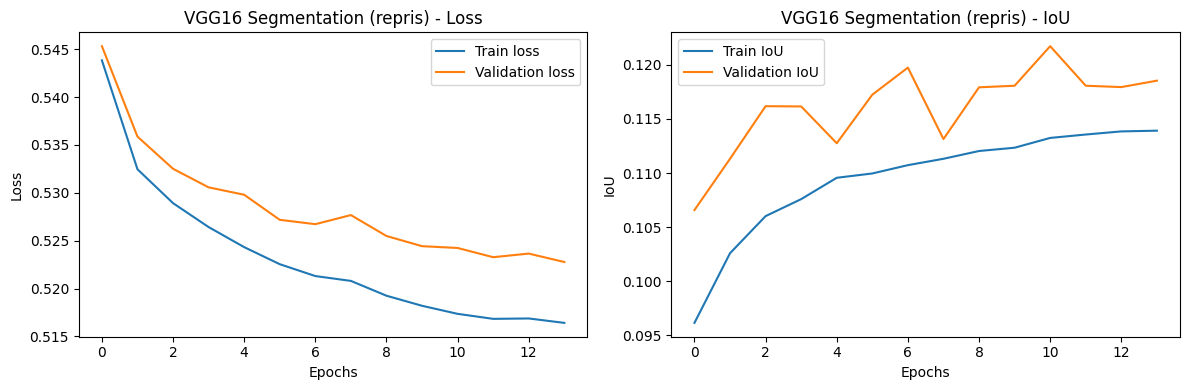

Valeurs uniques dans le masque original: [ 1  2  3  4  5  7  8  9 11 17 20 21 23 24 26]
Valeurs uniques après mapping: [0 1 2 3 4 5 6 7]
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Valeurs uniques dans la prédiction: [0 1]


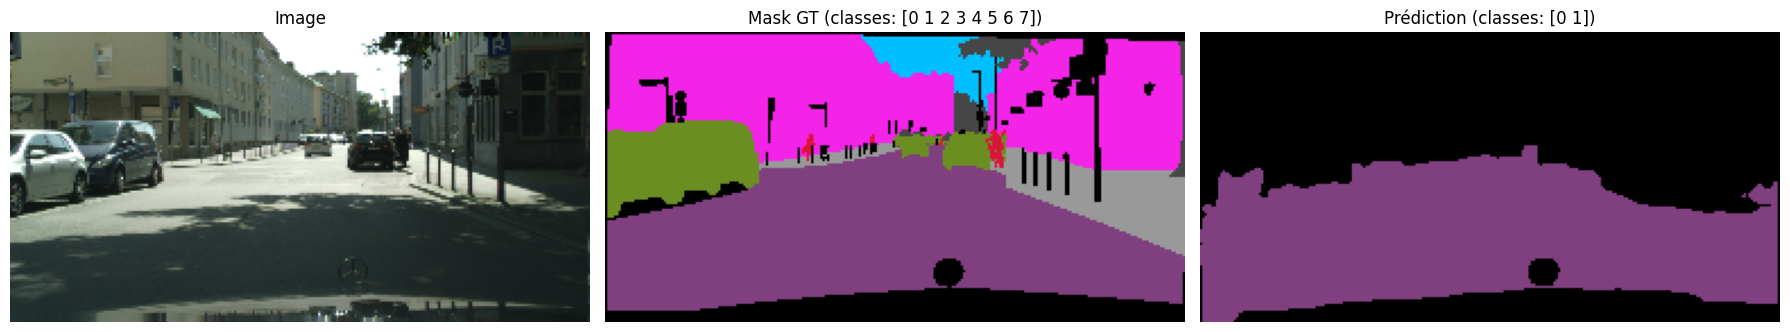

In [17]:
model_vgg16_resumed, history_vgg16_resumed = resume_vgg16_training()